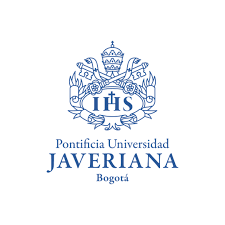
# **Big Data processing**

### classwork: **Clasification Classwork**

Name: Karla Cuéllar Mora

start date: 28/04/2026

actual date: 30/04/2026

# Classification Laboratory - Bank Marketing Dataset

This notebook develops a binary classification workflow using the Bank Marketing dataset. The objective is to predict whether a client subscribes to a term deposit (`y`) based on demographic, financial, and campaign-related variables.

The analysis is organized as follows:

1. Spark session and data loading.
2. Exploratory data analysis.
3. Individual analysis of categorical and numerical variables.
4. Data quality review.
5. Data cleaning and preparation.
6. Feature encoding and vector assembly.
7. Classification models.
8. Model evaluation and comparison.


### **1. Library import and Spark session**


In [1]:
# Import general-purpose libraries for numerical work, data manipulation, and visualization.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import specialized libraries required to initialize and use PySpark.
from pylab import *

import findspark
findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession

# Import PySpark tools for feature encoding, pipeline construction, and model evaluation.
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.stat import Correlation

# Import ROC tools from scikit-learn for graphical model evaluation.
from sklearn.metrics import roc_curve, auc

# Import classification models used in the notebook.

from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier,
    LinearSVC,
    MultilayerPerceptronClassifier
)

In [2]:
### Spark session setup.
# The Spark configuration defines the cluster connection and the application name.
configura = SparkConf()
configura.set("spark.scheduler.mode", "FAIR")
configura.set("spark.scheduler.allocation", "/Almacen/Spark/conf/fairscheduler.xml ")
configura.setMaster("spark://10.43.97.171:7077")
configura.setAppName("Banca_Cuellar_SPARK")

# A SparkSession is created to read, transform, and process the dataset in distributed mode.
sparkCuellar = SparkSession.builder.config(conf=configura).getOrCreate()

# SQLContext allows compatibility with SQL-style operations over Spark DataFrames.
SQLContext(sparkContext=sparkCuellar.sparkContext, sparkSession=sparkCuellar)

# The SparkContext is retrieved from the session to keep the cluster connection active.
sparkContextCuellar = sparkCuellar.sparkContext.getOrCreate()

sparkCuellar


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/24 04:09:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### **2. Dataset loading from HDFS**


In [3]:
# Import the dataset from HDFS.
# The file is read as a CSV file with header and semicolon separator.
df00 = sparkCuellar.read.format("csv").option("header", "true").option("sep", ";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv")

# The first five records are displayed to inspect the general structure of the dataset.
df00.show(5)


[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

### **3. Dataset description and initial inspection**


In [4]:
# Print the schema to identify the original data types of all columns.
df00.printSchema()


root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



### Initial comments

All variables are initially read as `string`. Therefore, the numerical variables must be converted to integer format before descriptive analysis, correlations, and model construction. The last column, `y`, is the target variable because it indicates whether the client subscribed to a term deposit.


In [5]:
# Count the total number of records in the dataset.
print(f"The dataset contains a total of {df00.count()} records.")


[Stage 2:=============================>                             (1 + 1) / 2]

The dataset contains a total of 45211 records.


In [6]:
# Display the name and current data type of each column using a Pandas DataFrame.
pd.DataFrame(df00.dtypes, columns=['Column_Name', 'Data_Type'])


,Column_Name,Data_Type
0,age,string
1,job,string
2,marital,string
3,education,string
4,default,string
5,balance,string
6,housing,string
7,loan,string
8,contact,string
9,day,string


In [7]:
# Display the list of variables available in the dataset.
df00.columns


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

### Data dictionary

| Role | Variable | Type | Description |
|---|---|---|---|
| Feature | age | Numeric | Client age |
| Feature | job | Categorical | Type of job |
| Feature | marital | Categorical | Marital status |
| Feature | education | Categorical | Education level |
| Feature | default | Binary | Whether the client has credit in default |
| Feature | balance | Numeric | Average yearly balance |
| Feature | housing | Binary | Whether the client has a housing loan |
| Feature | loan | Binary | Whether the client has a personal loan |
| Feature | contact | Categorical | Contact communication type |
| Feature | day | Numeric | Last contact day of the month |
| Feature | month | Categorical | Last contact month |
| Feature | duration | Numeric | Last contact duration in seconds |
| Feature | campaign | Numeric | Number of contacts during this campaign |
| Feature | pdays | Numeric | Days since the client was previously contacted; `-1` means not previously contacted |
| Feature | previous | Numeric | Number of contacts before this campaign |
| Feature | poutcome | Categorical | Outcome of the previous campaign |
| Target | y | Binary | Whether the client subscribed to a term deposit |


### **4. Data type transformation**


In [8]:
# The following columns are converted to integer type.
colINT = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# The string-to-integer transformation.
df01 = df00.withColumn("age", df00.age.cast("int"))
df01 = df01.withColumn("balance", df01.balance.cast("int"))
df01 = df01.withColumn("day", df01.day.cast("int"))
df01 = df01.withColumn("duration", df01.duration.cast("int"))
df01 = df01.withColumn("campaign", df01.campaign.cast("int"))
df01 = df01.withColumn("pdays", df01.pdays.cast("int"))
df01 = df01.withColumn("previous", df01.previous.cast("int"))


In [9]:
# Confirm that the numerical variables were correctly transformed.
pd.DataFrame(df01.dtypes, columns=['Column_Name', 'Data_Type'])


,Column_Name,Data_Type
0,age,int
1,job,string
2,marital,string
3,education,string
4,default,string
5,balance,int
6,housing,string
7,loan,string
8,contact,string
9,day,int


### Transformation analysis

After converting the numerical columns, the dataset is ready for quantitative exploration. This step is necessary because variables stored as text cannot be correctly used in histograms, boxplots, correlation matrices, or machine learning models that require numerical input.


### **5. Target variable balance**


In [10]:
# Review the balance of the target variable to identify possible class imbalance.
total = df01.count()
df_Y = df01.groupBy("y").count()
auxPD = df_Y.withColumn("Percentage", df_Y["count"] * 100 / total)
auxPD.show()


[Stage 8:>                                                          (0 + 2) / 2]

+---+-----+------------------+
|  y|count|        Percentage|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



### Target balance analysis

The target variable is clearly imbalanced. The class `no` represents the majority of records, while the class `yes` is the minority class. This is important because a classification model could obtain apparently high accuracy by mainly predicting the majority class. For that reason, later evaluation should consider metrics such as F1-score, confusion matrix, and ROC area, not only accuracy.


### **6. Descriptive statistics**


In [11]:
# Generate descriptive statistics for the dataset.
# For numerical variables, this helps identify scale, dispersion, minimum values, and maximum values.
df01.describe().toPandas()


26/05/24 04:10:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


### Descriptive statistics analysis

- The descriptive statistics provide an initial understanding of the variables in the dataset.

- In relation to the variable age:
    - The ages range approximately between 18 and 95 years.
    - The average age is around 40 years.
    - The standard deviation is close to 10 years, indicating moderate variability around the mean.
- In relation to the variable job:
    - Some categories appear more frequently than others.
    - The category unknown has a high frequency, meaning that many occupations were not registered.
    - Categories such as management appear less frequently.
- In relation to the variable duration (call duration in seconds):
    - The average call duration is approximately 258 seconds.
    - The variability is also high compared to the mean.
    - This indicates that some calls are very short while others are considerably longer.
- In relation to the variable campaign (number of contacts during the campaign):
    - The average number of contacts is around 2 to 3 attempts per client.
    - The dispersion indicates that some clients required many more contacts than others.
- In relation to the variable balance (client account balance):
    - The average balance is approximately 1362 euros.
    - The dispersion is relatively high, showing differences in the financial situation of the clients.
    - Some clients present very low balances, while others have much larger amounts.

- The descriptive table shows that the numerical variables have very different scales. These differences are relevant because they help detect atypical values and variables that require special treatment before modeling.



### **7. Frequency tables for categorical variables**


In [12]:
# Frequency table for the categorical variable 'job'.
# This table shows how many clients belong to each category.
df01.groupBy('job').count().orderBy(F.desc('count')).show()


+-------------+-----+
|          job|count|
+-------------+-----+
|  blue-collar| 9732|
|   management| 9458|
|   technician| 7597|
|       admin.| 5171|
|     services| 4154|
|      retired| 2264|
|self-employed| 1579|
| entrepreneur| 1487|
|   unemployed| 1303|
|    housemaid| 1240|
|      student|  938|
|      unknown|  288|
+-------------+-----+



### Analysis of `job`

This table helps identify which occupations are most common in the database. Categories with very high frequency like blue-collar may dominate the patterns learned by the model, while very rare occupations like student may provide less stable information.


In [13]:
# Frequency table for the categorical variable 'marital'.
# This table shows how many clients belong to each category.
df01.groupBy('marital').count().orderBy(F.desc('count')).show()


+--------+-----+
| marital|count|
+--------+-----+
| married|27214|
|  single|12790|
|divorced| 5207|
+--------+-----+



### Analysis of `marital`

This table shows the distribution of clients by marital status. It is useful to observe whether the dataset is concentrated in one group or if the marital categories are reasonably represented.


In [14]:
# Frequency table for the categorical variable 'education'.
# This table shows how many clients belong to each category.
df01.groupBy('education').count().orderBy(F.desc('count')).show()


+---------+-----+
|education|count|
+---------+-----+
|secondary|23202|
| tertiary|13301|
|  primary| 6851|
|  unknown| 1857|
+---------+-----+



### Analysis of `education`

This table allows the education levels to be compared. The presence of `unknown` should be considered because it represents missing or unspecified information rather than a standard educational category.


In [15]:
# Frequency table for the categorical variable 'default'.
# This table shows how many clients belong to each category.
df01.groupBy('default').count().orderBy(F.desc('count')).show()


+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+



### Analysis of `default`

This binary variable indicates whether the client has credit in default. A very small `yes` category would suggest that default status is uncommon in this dataset.


In [16]:
# Frequency table for the categorical variable 'housing'.
# This table shows how many clients belong to each category.
df01.groupBy('housing').count().orderBy(F.desc('count')).show()


+-------+-----+
|housing|count|
+-------+-----+
|    yes|25130|
|     no|20081|
+-------+-----+



### Analysis of `housing`

This table shows the number of clients with and without housing loans. Since financial commitments may influence the decision to subscribe to a deposit, this variable can be relevant for classification.


In [17]:
# Frequency table for the categorical variable 'loan'.
# This table shows how many clients belong to each category.
df01.groupBy('loan').count().orderBy(F.desc('count')).show()


+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+



### Analysis of `loan`

This table identifies whether clients have a personal loan. The distribution is important because debt obligations may be associated with a lower probability of accepting new financial products.


In [18]:
# Frequency table for the categorical variable 'contact'.
# This table shows how many clients belong to each category.
df01.groupBy('contact').count().orderBy(F.desc('count')).show()


+---------+-----+
|  contact|count|
+---------+-----+
| cellular|29285|
|  unknown|13020|
|telephone| 2906|
+---------+-----+



### Analysis of `contact`

This variable describes the communication channel used. A high concentration in one contact type may indicate that the campaign relied more heavily on that channel.


In [19]:
# Frequency table for the categorical variable 'month'.
# This table shows how many clients belong to each category.
df01.groupBy('month').count().orderBy(F.desc('count')).show()


+-----+-----+
|month|count|
+-----+-----+
|  may|13766|
|  jul| 6895|
|  aug| 6247|
|  jun| 5341|
|  nov| 3970|
|  apr| 2932|
|  feb| 2649|
|  jan| 1403|
|  oct|  738|
|  sep|  579|
|  mar|  477|
|  dec|  214|
+-----+-----+



### Analysis of `month`

This table helps identify seasonality in the marketing campaign. Some months may have more contacts, which can affect the distribution of positive responses.


In [20]:
# Frequency table for the categorical variable 'poutcome'.
# This table shows how many clients belong to each category.
df01.groupBy('poutcome').count().orderBy(F.desc('count')).show()


+--------+-----+
|poutcome|count|
+--------+-----+
| unknown|36959|
| failure| 4901|
|   other| 1840|
| success| 1511|
+--------+-----+



### Analysis of `poutcome`

This variable summarizes the outcome of the previous campaign. The category `unknown` is usually frequent because many clients were not previously contacted.


In [21]:
# Frequency table for the categorical variable 'y'.
# This table shows how many clients belong to each category.
df01.groupBy('y').count().orderBy(F.desc('count')).show()


+---+-----+
|  y|count|
+---+-----+
| no|39922|
|yes| 5289|
+---+-----+



### Analysis of `y`

This table confirms the imbalance of the target variable and reinforces the need to evaluate the model beyond simple accuracy.


### **8. Histograms for numerical variables**


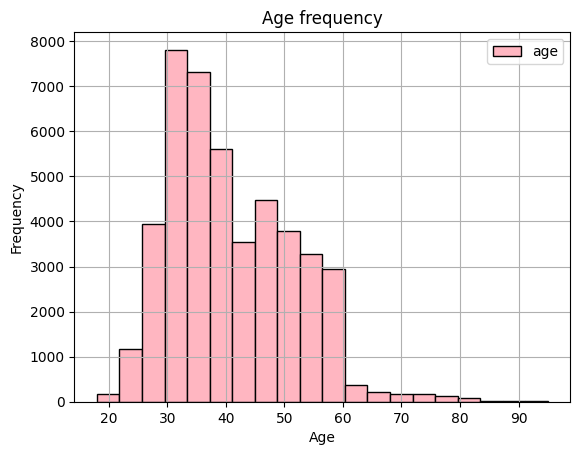

In [22]:
# Histogram for 'age'.
# This graph shows the distribution, concentration, and possible atypical values of the variable.
histGra = df01.select('age').toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightpink')
plt.ylabel("Frequency")
plt.xlabel('age'.capitalize())
plt.title('age'.capitalize() + " frequency")
plt.grid()
plt.show()


### Analysis of the `age` histogram

The age histogram is used to understand the main age range of contacted clients. It also helps detect whether the campaign is concentrated on working-age clients and whether older ages appear as low-frequency values.


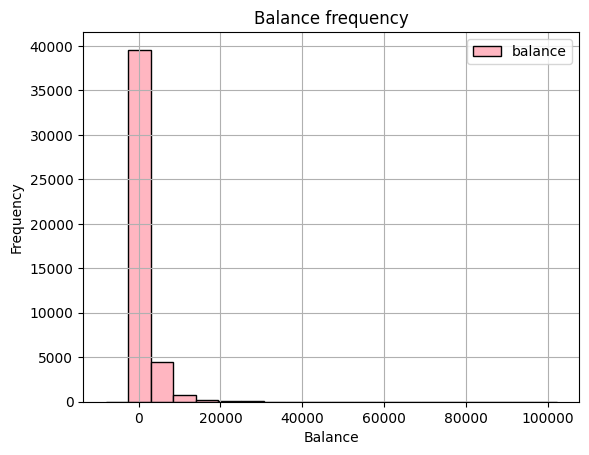

In [23]:
# Histogram for 'balance'.
# This graph shows the distribution, concentration, and possible atypical values of the variable.
histGra = df01.select('balance').toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightpink')
plt.ylabel("Frequency")
plt.xlabel('balance'.capitalize())
plt.title('balance'.capitalize() + " frequency")
plt.grid()
plt.show()


### Analysis of the `balance` histogram

The balance histogram usually shows strong dispersion because account balances may include negative values and very high positive values. This variable should be interpreted carefully because extreme balances can affect summary statistics.


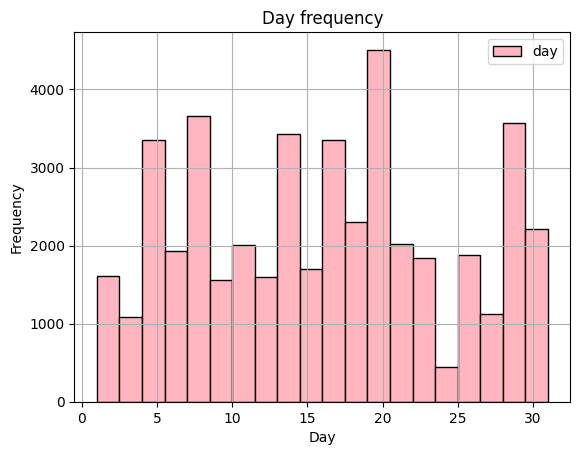

In [24]:
# Histogram for 'day'.
# This graph shows the distribution, concentration, and possible atypical values of the variable.
histGra = df01.select('day').toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightpink')
plt.ylabel("Frequency")
plt.xlabel('day'.capitalize())
plt.title('day'.capitalize() + " frequency")
plt.grid()
plt.show()


### Analysis of the `day` histogram

The day histogram shows how contacts are distributed across the days of the month. Peaks in specific days may reflect campaign scheduling decisions rather than client characteristics.


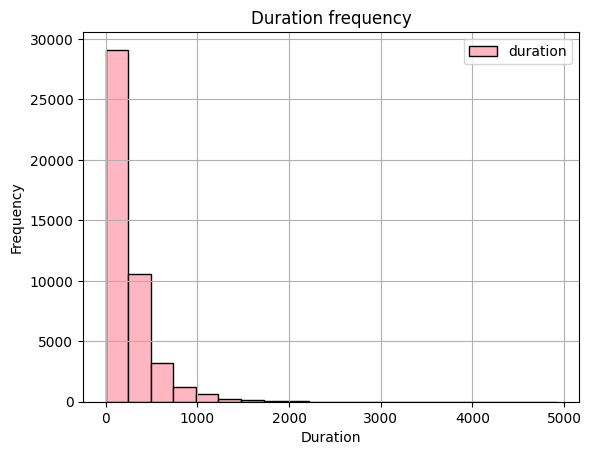

In [25]:
# Histogram for 'duration'.
# This graph shows the distribution, concentration, and possible atypical values of the variable.
histGra = df01.select('duration').toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightpink')
plt.ylabel("Frequency")
plt.xlabel('duration'.capitalize())
plt.title('duration'.capitalize() + " frequency")
plt.grid()
plt.show()


### Analysis of the `duration` histogram

The duration histogram is important because longer calls tend to be associated with a greater probability of subscription. However, this variable should be handled cautiously because call duration is only known after the contact occurs.


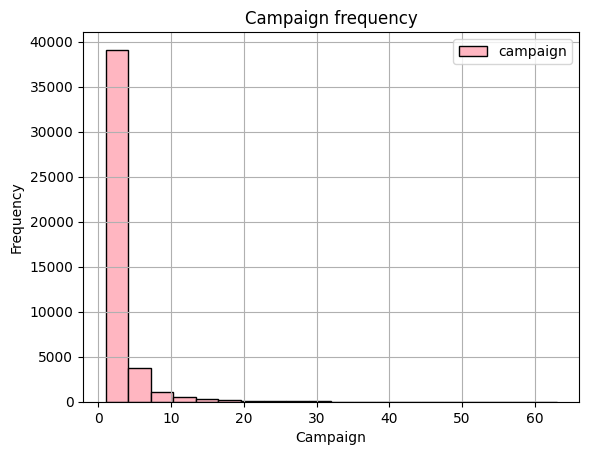

In [26]:
# Histogram for 'campaign'.
# This graph shows the distribution, concentration, and possible atypical values of the variable.
histGra = df01.select('campaign').toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightpink')
plt.ylabel("Frequency")
plt.xlabel('campaign'.capitalize())
plt.title('campaign'.capitalize() + " frequency")
plt.grid()
plt.show()


### Analysis of the `campaign` histogram

The campaign histogram shows how many contacts were made during the current campaign. Most clients are usually contacted only a few times, while high values may represent atypical or persistent contact cases.


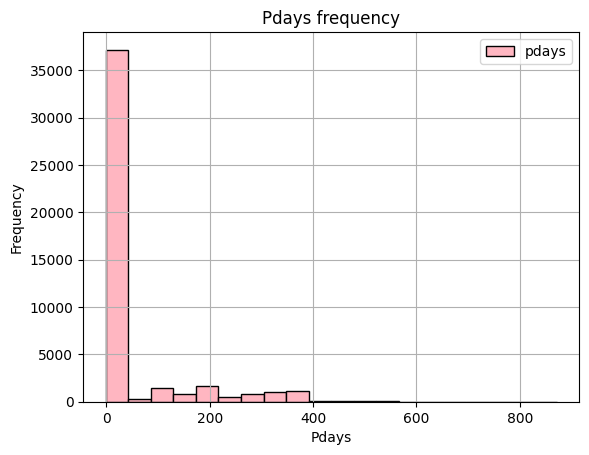

In [27]:
# Histogram for 'pdays'.
# This graph shows the distribution, concentration, and possible atypical values of the variable.
histGra = df01.select('pdays').toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightpink')
plt.ylabel("Frequency")
plt.xlabel('pdays'.capitalize())
plt.title('pdays'.capitalize() + " frequency")
plt.grid()
plt.show()


### Analysis of the `pdays` histogram

The pdays histogram must be interpreted considering that `-1` means the client was not previously contacted. Therefore, the distribution combines a special code with actual day counts.


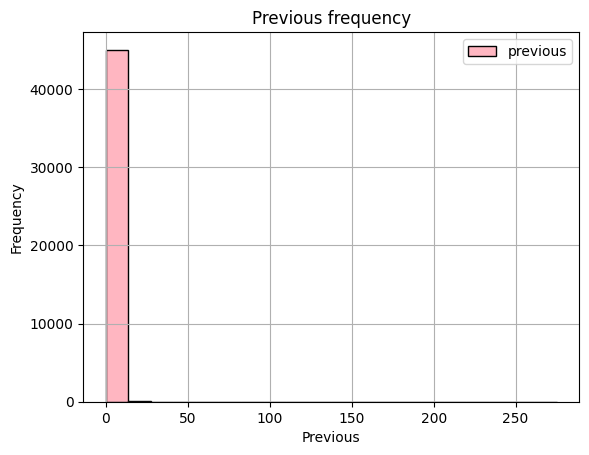

In [28]:
# Histogram for 'previous'.
# This graph shows the distribution, concentration, and possible atypical values of the variable.
histGra = df01.select('previous').toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightpink')
plt.ylabel("Frequency")
plt.xlabel('previous'.capitalize())
plt.title('previous'.capitalize() + " frequency")
plt.grid()
plt.show()


### Analysis of the `previous` histogram

The previous histogram shows the number of contacts before the current campaign. High values are usually uncommon and may indicate atypical historical contact intensity.


### **9. Boxplots for numerical variables by target variable**

A boxplot is a graphical representation used to summarize the distribution of a numerical variable through its quartiles, median, and possible outliers. It is important because it allows us to easily identify the central tendency, variability, asymmetry, and extreme values of the data. Additionally, boxplots are useful for comparing the behavior of variables between different groups or classes in a classification problem.

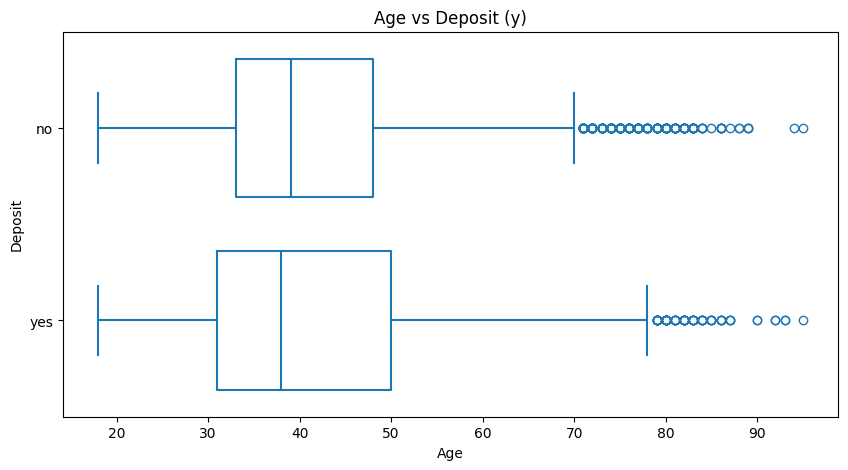

In [29]:
# Boxplot for 'age' against the target variable.
# This graph compares the distribution of the numerical variable between clients who subscribed and clients who did not.
plt.figure(figsize=(10, 5))
sns.boxplot(x='age', y='y', data=df01.toPandas(), fill=False, gap=.1)
plt.title('age'.capitalize() + " vs Deposit (y)")
plt.xlabel('age'.capitalize())
plt.ylabel("Deposit")
plt.show()


### Comments and Observations for `age` vs `y`
- Most contacted clients are between 30 and 50 years old.
- Clients older than approximately 70 years appear as outliers.
- The median age is concentrated around middle-aged customers.
- The distribution between subscribed and non-subscribed clients is relatively similar, although subscribed clients tend to show slightly higher ages.

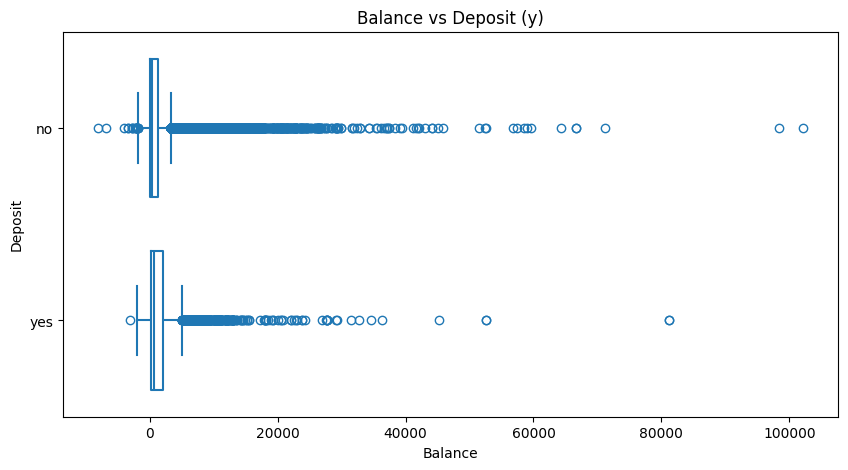

In [30]:
# Boxplot for 'balance' against the target variable.
# This graph compares the distribution of the numerical variable between clients who subscribed and clients who did not.
plt.figure(figsize=(10, 5))
sns.boxplot(x='balance', y='y', data=df01.toPandas(), fill=False, gap=.1)
plt.title('balance'.capitalize() + " vs Deposit (y)")
plt.xlabel('balance'.capitalize())
plt.ylabel("Deposit")
plt.show()


### Comments and Observations for `balance` vs `y`
- Most client balances are concentrated around low to medium values.
- Several extreme positive balances appear as outliers.
- Some clients also present negative balances.
- The variability is high, indicating important differences in the financial conditions of the customers.


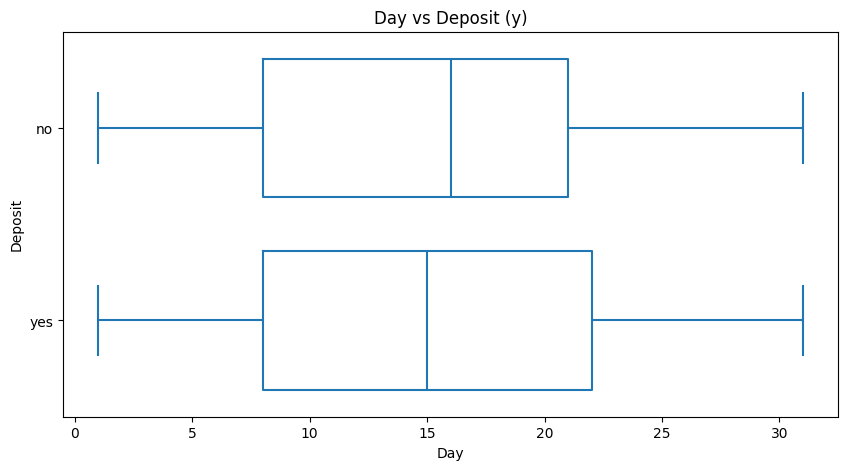

In [31]:
# Boxplot for 'day' against the target variable.
# This graph compares the distribution of the numerical variable between clients who subscribed and clients who did not.
plt.figure(figsize=(10, 5))
sns.boxplot(x='day', y='y', data=df01.toPandas(), fill=False, gap=.1)
plt.title('day'.capitalize() + " vs Deposit (y)")
plt.xlabel('day'.capitalize())
plt.ylabel("Deposit")
plt.show()


### Comments and Observations for `day` vs `y`

- Most contacts were made between days 8 and 21 of the month.
- There are no strong extreme outliers in this variable.
- The distribution is relatively concentrated around the middle days of the month.
- Both classes present similar contact day behavior.


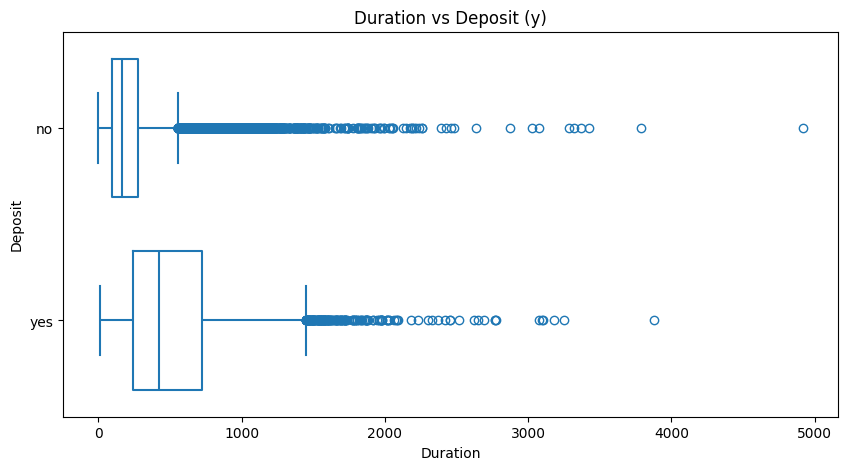

In [32]:
# Boxplot for 'duration' against the target variable.
# This graph compares the distribution of the numerical variable between clients who subscribed and clients who did not.
plt.figure(figsize=(10, 5))
sns.boxplot(x='duration', y='y', data=df01.toPandas(), fill=False, gap=.1)
plt.title('duration'.capitalize() + " vs Deposit (y)")
plt.xlabel('duration'.capitalize())
plt.ylabel("Deposit")
plt.show()


### Comments and Observations for `duration` vs `y`

- Most calls have durations below 700 seconds.
- Calls longer than approximately 1500 seconds are considered outliers.
- Clients who subscribed generally show longer call durations.
- The variable presents strong right skewness due to extremely long calls.


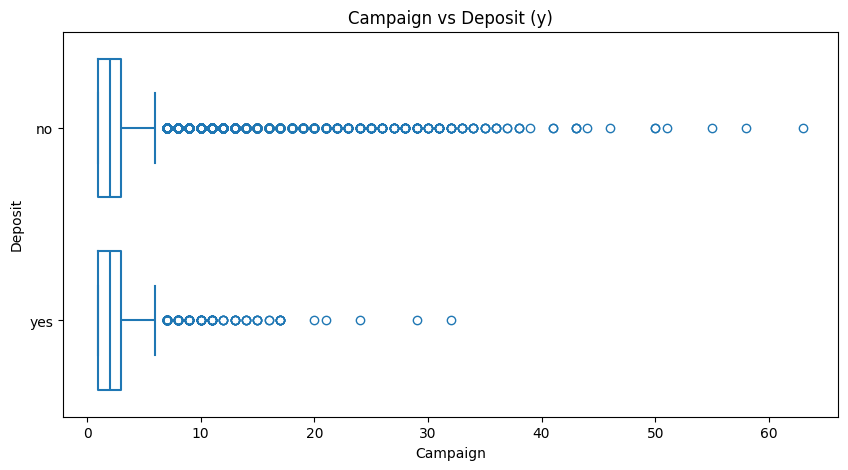

In [33]:
# Boxplot for 'campaign' against the target variable.
# This graph compares the distribution of the numerical variable between clients who subscribed and clients who did not.
plt.figure(figsize=(10, 5))
sns.boxplot(x='campaign', y='y', data=df01.toPandas(), fill=False, gap=.1)
plt.title('campaign'.capitalize() + " vs Deposit (y)")
plt.xlabel('campaign'.capitalize())
plt.ylabel("Deposit")
plt.show()


### Comments and Observations for `campaign` vs `y`

- Most clients were contacted between 1 and 3 times during the campaign.
- Values above approximately 8 contacts are considered outliers.
- The majority of successful subscriptions occur with fewer contacts.
- Higher numbers of contacts may indicate difficulties in customer conversion.

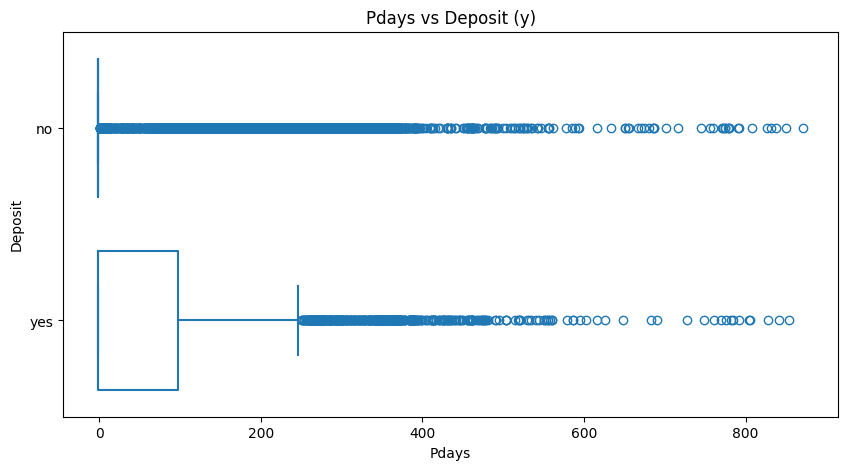

In [34]:
# Boxplot for 'pdays' against the target variable.
# This graph compares the distribution of the numerical variable between clients who subscribed and clients who did not.
plt.figure(figsize=(10, 5))
sns.boxplot(x='pdays', y='y', data=df01.toPandas(), fill=False, gap=.1)
plt.title('pdays'.capitalize() + " vs Deposit (y)")
plt.xlabel('pdays'.capitalize())
plt.ylabel("Deposit")
plt.show()


### Comments and Observations for `pdays` vs `y`

- Most clients have values concentrated near 0, indicating they were not previously contacted.
- Higher values appear as outliers.
- Clients with successful subscriptions tend to present lower pdays values.
- The distribution is highly asymmetric.

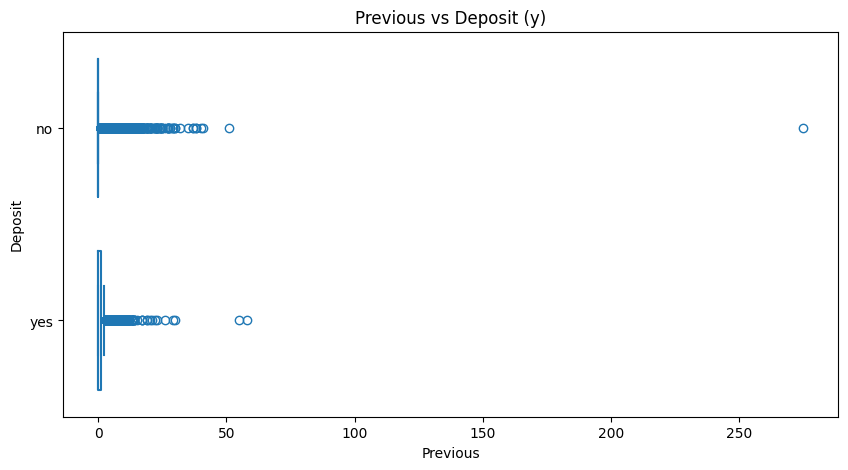

In [35]:
# Boxplot for 'previous' against the target variable.
# This graph compares the distribution of the numerical variable between clients who subscribed and clients who did not.
plt.figure(figsize=(10, 5))
sns.boxplot(x='previous', y='y', data=df01.toPandas(), fill=False, gap=.1)
plt.title('previous'.capitalize() + " vs Deposit (y)")
plt.xlabel('previous'.capitalize())
plt.ylabel("Deposit")
plt.show()


### Comments and Observations for `previous` vs `y`

- Most clients had 0 previous contacts before the current campaign.
- Values greater than 0 are less frequent and may be considered outliers.
- The variable shows strong concentration in low values.
- Some subscribed clients present slightly higher previous contact counts.

### **10. Correlation matrix for numerical variables and the target**

- An auxiliary DataFrame is created using only the numerical variables to simplify the analysis.
- The target variable `y` is transformed into binary format, where `yes = 1` and `no = 0`.
- This transformation allows the variable to be used in classification models.
- Separating numerical variables also facilitates preprocessing and visualization tasks.

In [36]:
# Select numerical variables and the target variable.
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
dfauxNum = df01.select(colNum + ['y'])

# Convert the target variable into numerical format: yes = 1, no = 0.
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == 'yes', 1).otherwise(0))

dfauxNum.show(5)


+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [37]:
# Assemble the numerical variables and the target into a single vector column.
# This is required because PySpark's Correlation function works with vectorized features.
assembler = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')

# Create a vectorized DataFrame containing all numerical variables and the target.
dfNumVector = assembler.transform(dfauxNum).select('features')


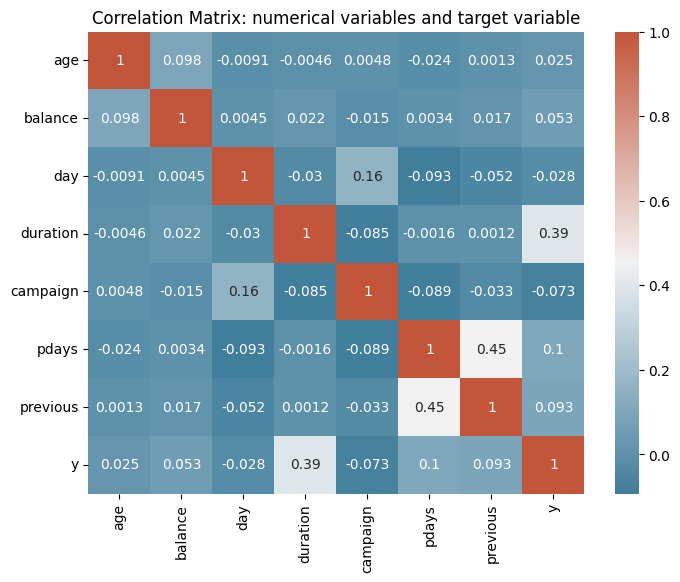

In [38]:
# Compute the Pearson correlation matrix.
corrMatrix = Correlation.corr(dfNumVector, 'features').head()

# Convert the Spark matrix into a NumPy array.
corrVector = corrMatrix[0].toArray()

# Create a Pandas DataFrame to label the rows and columns of the correlation matrix.
dfCorrelation = pd.DataFrame(corrVector, columns=dfauxNum.columns, index=dfauxNum.columns)

# Generate a custom diverging color map for the heatmap.
cmapKarla = sns.diverging_palette(230, 20, as_cmap=True)

plt.figure(figsize=(8, 6))
sns.heatmap(dfCorrelation, annot=True, cmap=cmapKarla)
plt.title("Correlation Matrix: numerical variables and target variable")
plt.show()


### Correlation analysis between variables
`age` vs `y`

The correlation between age and y is low, suggesting that age alone does not strongly influence whether a client subscribes to the service.

`balance` vs `y`

The variable balance shows a weak positive correlation with y, indicating that clients with higher balances may have a slightly higher probability of subscription.

`duration` vs `y`

The variable duration presents the strongest correlation with y, meaning that longer calls are associated with a higher probability of subscription.

However, according to the dataset source, this variable should not be included in predictive models because the call duration is only known after the interaction has finished, meaning the answer would already be partially known.

`campaign` vs `y`

The correlation between campaign and y is negative and weak, suggesting that a larger number of contacts does not necessarily increase subscription probability.

`pdays` vs `y`

The variable pdays has a low correlation with y, although previous contact history may still provide useful information for the models.

`previous` vs `y`

The correlation between previous and y is weak, indicating a limited direct relationship with the target variable.

`pdays` vs `previous`

A moderate correlation exists between pdays and previous, suggesting that both variables contain related information about previous customer contacts. This may generate redundancy in some predictive models.

### **11. Pairplot for numerical variables**

The pairplot allows the relationships between the numerical variables to be visualized simultaneously. Using hue = "y" colors the observations according to the target variable, making it easier to identify possible separations or patterns between the classes.

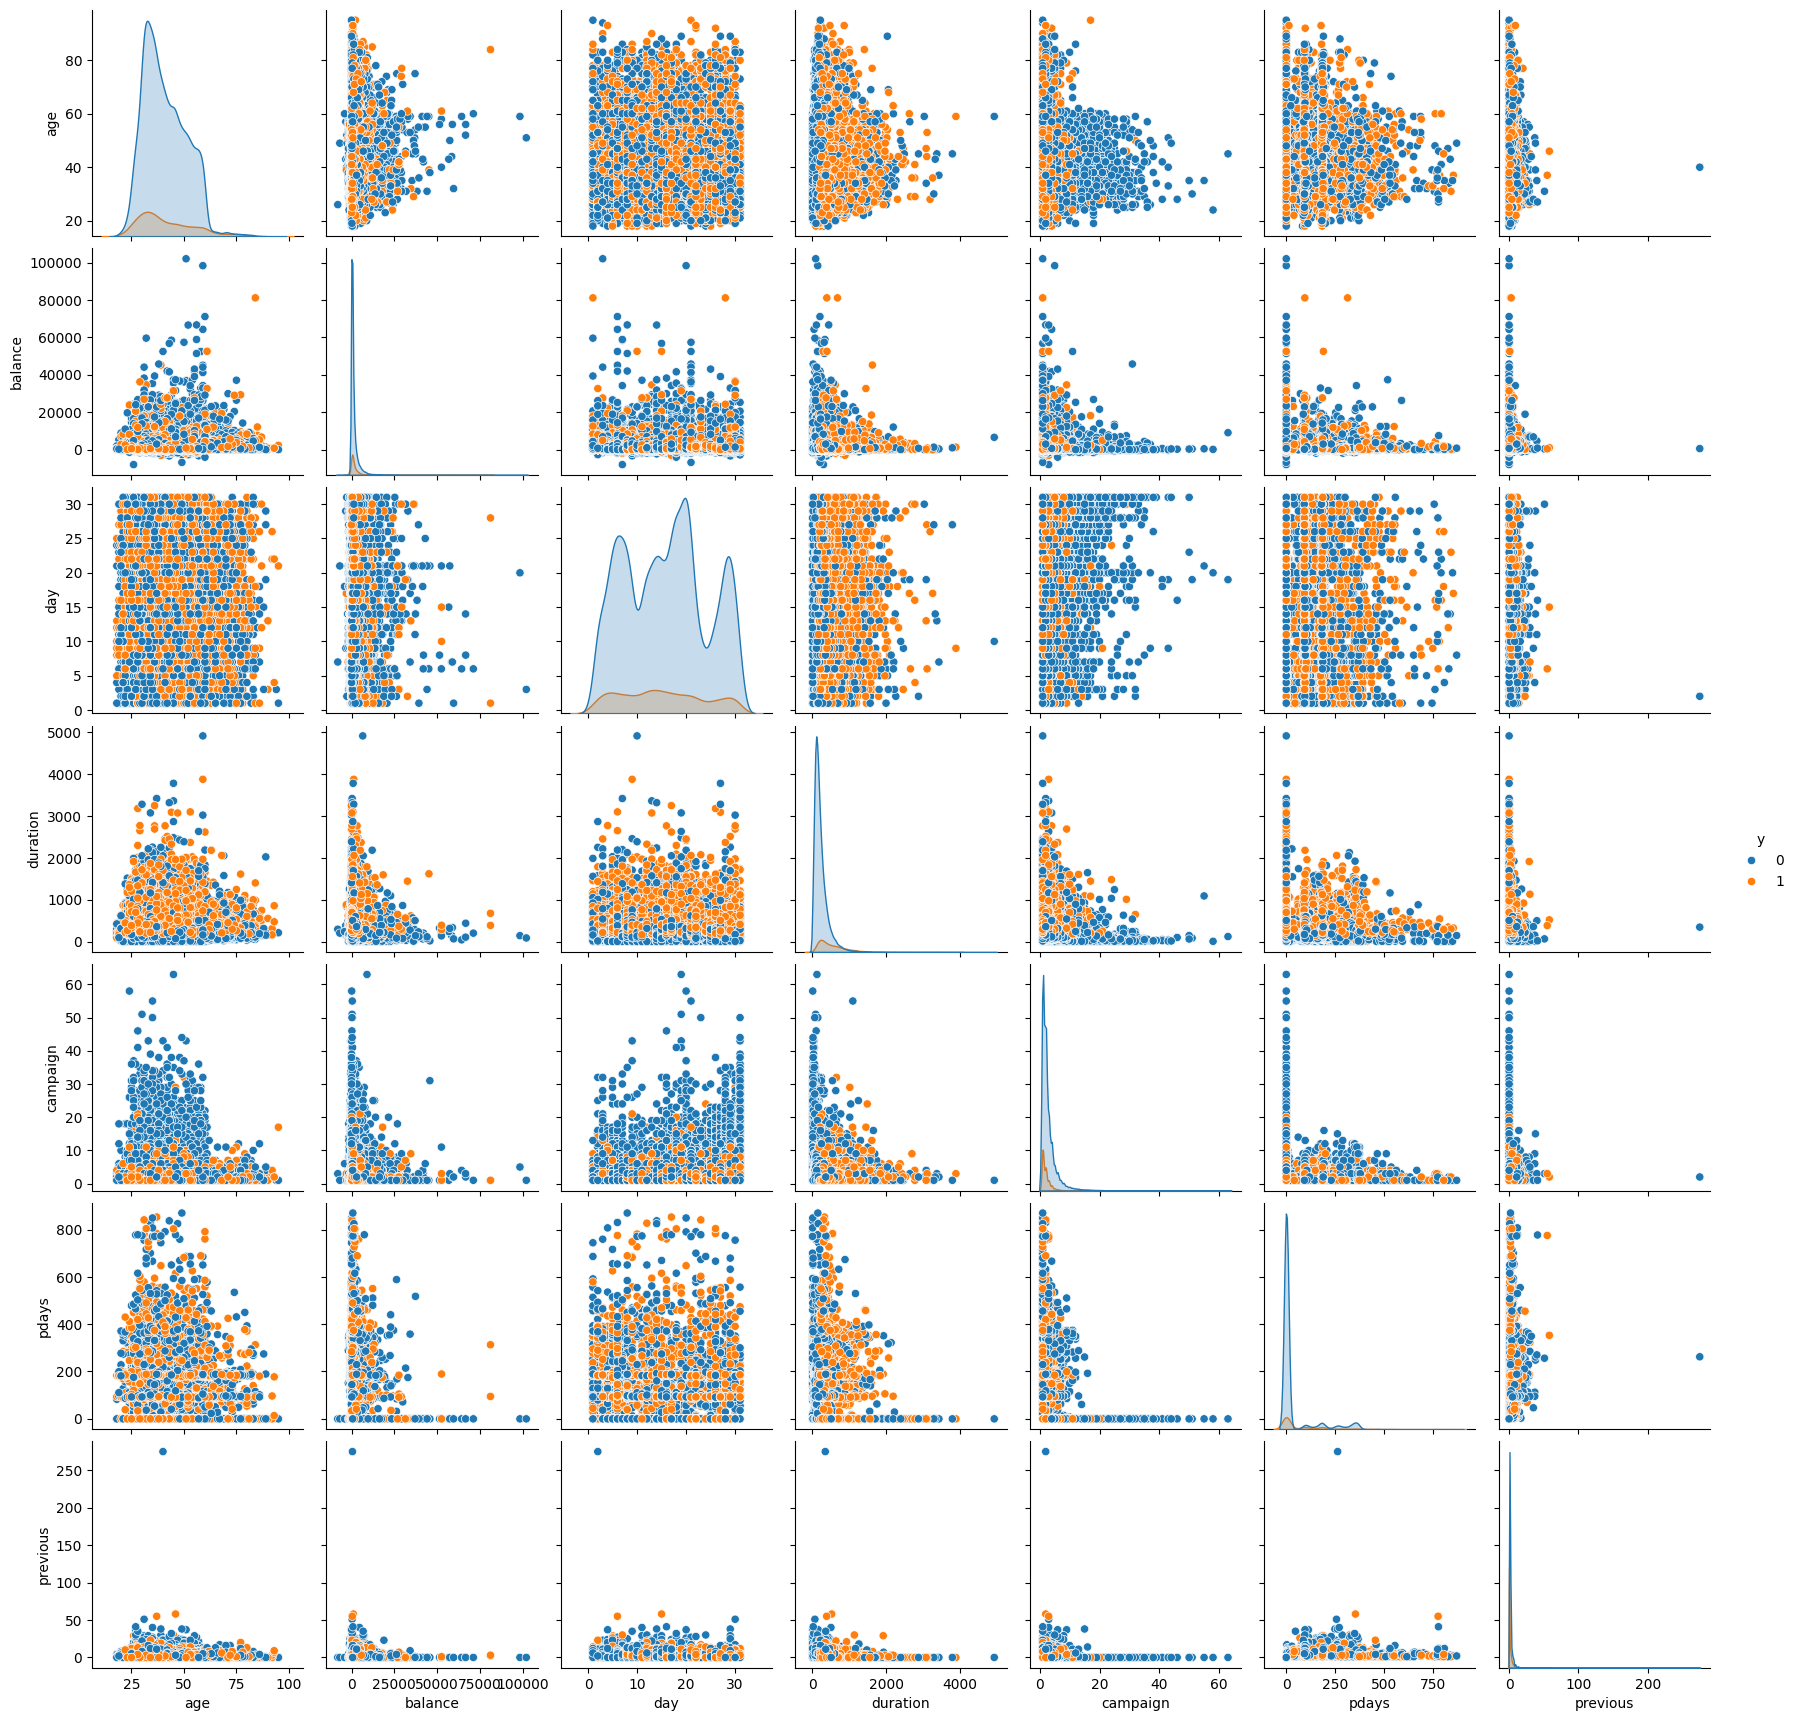

In [39]:
# Pairplot for all numerical variables and the target variable.
# This graph provides a general view of pairwise relationships, dispersion, and possible separation between classes.
sns.pairplot(dfauxNum.toPandas(), kind='scatter', hue='y')
plt.show()


### Pairplot analysis

The pairplot provides a general visualization of the relationships between the numerical variables. It can be observed that some variables, such as `duration`, show a clearer separation between the classes, suggesting a stronger relationship with the target variable `y`.

Most variable combinations do not present strong linear patterns, indicating low pairwise correlations between several predictors. Additionally, some extreme observations can be identified, especially in variables such as `balance` and `duration`, where the dispersion is considerably larger than in the other variables.

Overall, the pairplot helps identify possible class separation patterns and variables that may contribute more strongly to the classification models.

### **12. Pie charts for binary categorical variables**

- default
- housing
- loan

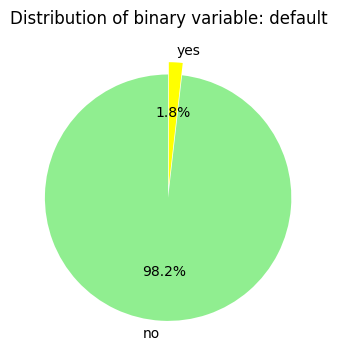

In [40]:
# Pie chart for the binary variable 'default'.
# The graph displays the percentage participation of each category.
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']

plt.figure(figsize=(5, 4))

cantBin = df01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(
    kind='pie',
    explode=explode,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of binary variable: default')
plt.ylabel('')
plt.show()


### Analysis of `default` pie chart

The `default` pie chart shows whether most clients have credit in default. If the `yes` category is very small, this variable may still be useful but should be interpreted with caution because the minority category has limited representation.


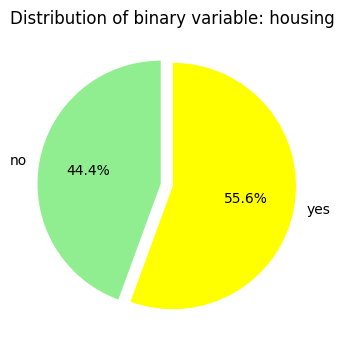

In [41]:
# Pie chart for the binary variable 'housing'.
# The graph displays the percentage participation of each category.
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']

plt.figure(figsize=(5, 4))

cantBin = df01.groupBy('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(
    kind='pie',
    explode=explode,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of binary variable: housing')
plt.ylabel('')
plt.show()


### Analysis of `housing` pie chart

The `housing` pie chart shows the proportion of clients with a housing loan. This variable can be relevant because clients with long-term financial obligations may respond differently to deposit offers.


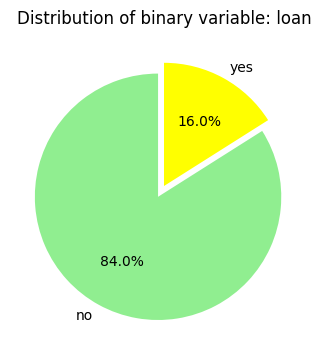

In [42]:
# Pie chart for the binary variable 'loan'.
# The graph displays the percentage participation of each category.
explode = (0.1, 0)
colors = ['lightgreen', 'yellow']

plt.figure(figsize=(5, 4))

cantBin = df01.groupBy('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(
    kind='pie',
    explode=explode,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of binary variable: loan')
plt.ylabel('')
plt.show()


### Analysis of `loan` pie chart

The `loan` pie chart shows the proportion of clients with personal loans. This is useful because personal debt may influence the client's willingness or ability to subscribe to a term deposit.


### **13. Bar charts for multi-category variables**


<Figure size 800x600 with 0 Axes>

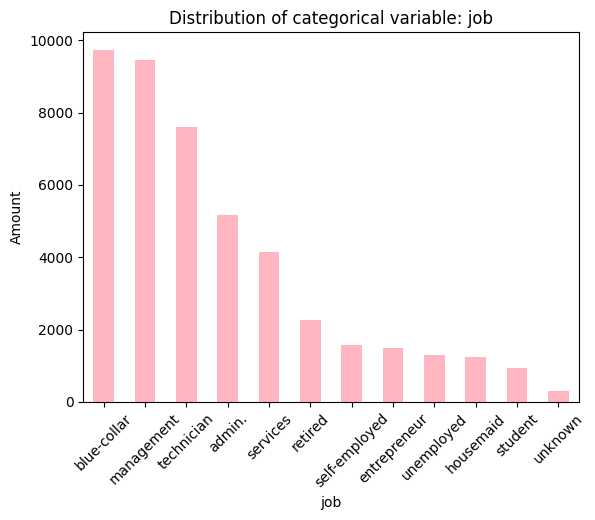

In [43]:
# Bar chart for the categorical variable 'job'.
# The categories are ordered from highest to lowest frequency.
cantMulti = df01.groupBy('job').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='job', y='count', legend=None, color='lightpink')
plt.xlabel('job')
plt.ylabel('Amount')
plt.title('Distribution of categorical variable: job')
plt.xticks(rotation=45)
plt.show()


### Analysis of `job` bar chart

The job distribution helps identify the occupational groups most represented in the campaign. High-frequency groups may have more influence on the model, while low-frequency categories can be harder to learn from.


<Figure size 800x600 with 0 Axes>

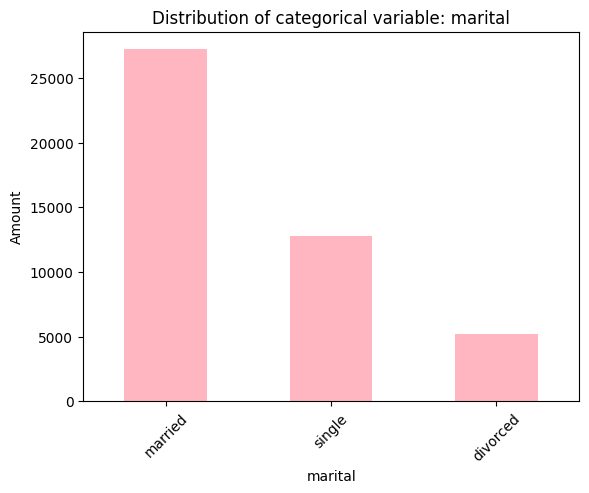

In [44]:
# Bar chart for the categorical variable 'marital'.
# The categories are ordered from highest to lowest frequency.
cantMulti = df01.groupBy('marital').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='marital', y='count', legend=None, color='lightpink')
plt.xlabel('marital')
plt.ylabel('Amount')
plt.title('Distribution of categorical variable: marital')
plt.xticks(rotation=45)
plt.show()


### Analysis of `marital` bar chart

The marital status distribution shows whether the client base is mainly composed of married, single, or divorced clients. This profile may be associated with financial stability and product acceptance.


<Figure size 800x600 with 0 Axes>

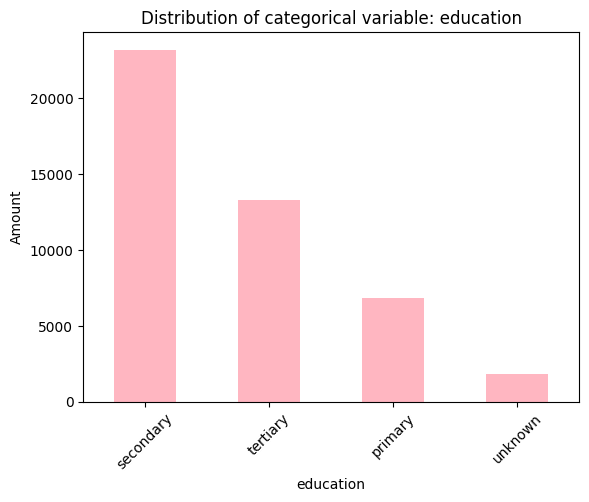

In [45]:
# Bar chart for the categorical variable 'education'.
# The categories are ordered from highest to lowest frequency.
cantMulti = df01.groupBy('education').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='education', y='count', legend=None, color='lightpink')
plt.xlabel('education')
plt.ylabel('Amount')
plt.title('Distribution of categorical variable: education')
plt.xticks(rotation=45)
plt.show()


### Analysis of `education` bar chart

The education distribution allows the comparison of formal education levels. The `unknown` category should be considered as a data quality issue or an unspecified client profile.


<Figure size 800x600 with 0 Axes>

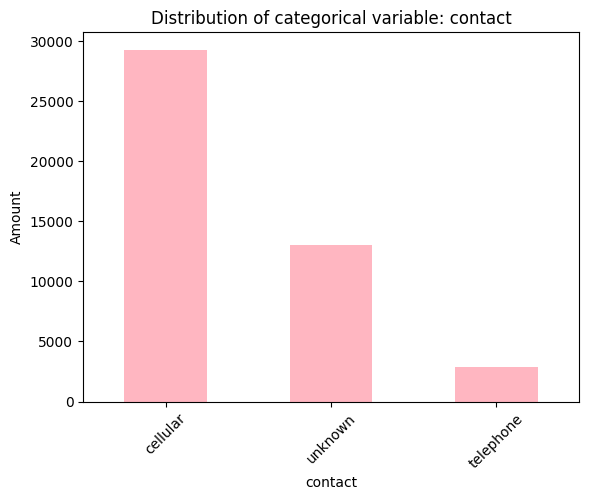

In [46]:
# Bar chart for the categorical variable 'contact'.
# The categories are ordered from highest to lowest frequency.
cantMulti = df01.groupBy('contact').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='contact', y='count', legend=None, color='lightpink')
plt.xlabel('contact')
plt.ylabel('Amount')
plt.title('Distribution of categorical variable: contact')
plt.xticks(rotation=45)
plt.show()


### Analysis of `contact` bar chart

The contact distribution shows which communication channel was used most frequently. This can reveal operational patterns in the campaign strategy.


<Figure size 800x600 with 0 Axes>

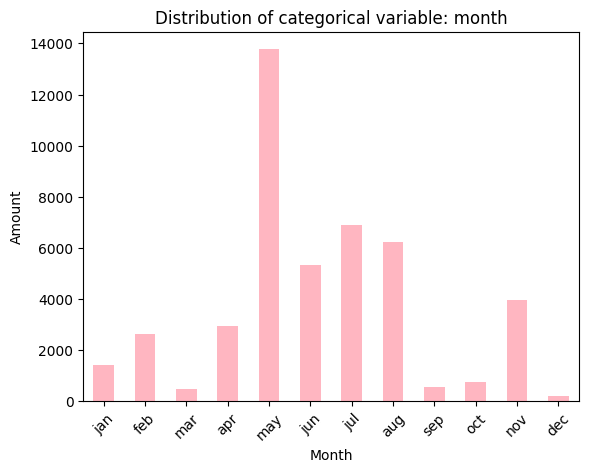

In [47]:
# Bar chart for the categorical variable 'month'.
# The months are displayed in chronological order.

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

cantMulti = df01.groupBy('month').count().toPandas()

# Convert month to categorical type with the correct order
cantMulti['month'] = pd.Categorical(
    cantMulti['month'],
    categories=month_order,
    ordered=True
)

# Sort by chronological order
cantMulti = cantMulti.sort_values('month')

plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='month', y='count', legend=None, color='lightpink')

plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Distribution of categorical variable: month')
plt.xticks(rotation=45)

plt.show()

### Analysis of `month` bar chart

The month distribution helps identify the periods with the highest campaign activity. Differences by month may reflect seasonality or campaign planning.


<Figure size 800x600 with 0 Axes>

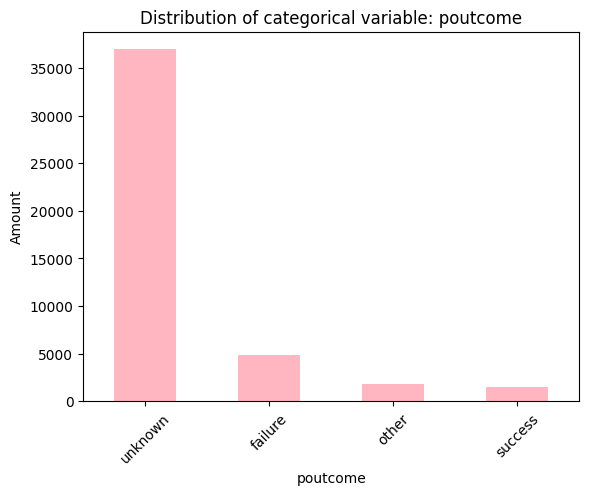

In [48]:
# Bar chart for the categorical variable 'poutcome'.
# The categories are ordered from highest to lowest frequency.
cantMulti = df01.groupBy('poutcome').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)

plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='poutcome', y='count', legend=None, color='lightpink')
plt.xlabel('poutcome')
plt.ylabel('Amount')
plt.title('Distribution of categorical variable: poutcome')
plt.xticks(rotation=45)
plt.show()


### Analysis of `poutcome` bar chart

The previous outcome distribution is important because `success`, `failure`, and `unknown` can capture whether past marketing interactions provide useful information for the current response.


### **14. Grouped bar charts: categorical variables vs target variable**


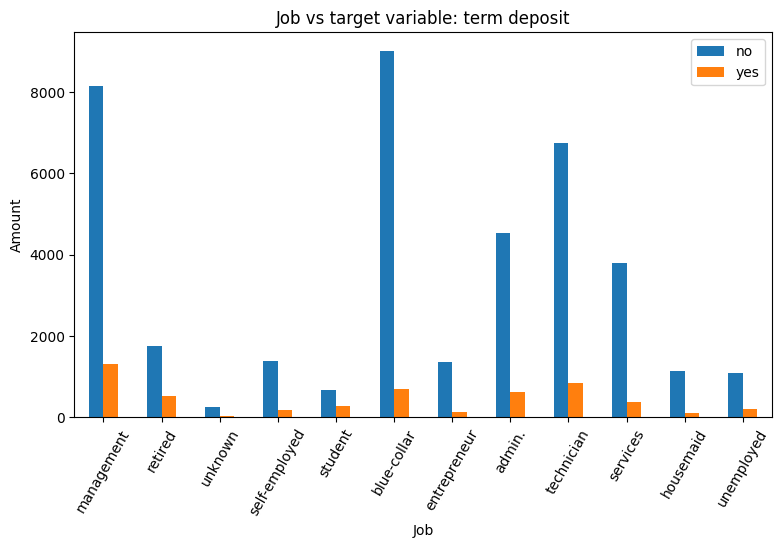

In [49]:
# Cross-tabulation between 'job' and the target variable.
# The grouped bar chart shows how each category is distributed across 'yes' and 'no' outcomes.
cratab_job = df01.crosstab('job', 'y').toPandas()
cratab_job.set_index('job_y').plot(kind='bar', figsize=(9, 5))
plt.xlabel('Job')
plt.ylabel('Amount')
plt.title('Job vs target variable: term deposit')
plt.xticks(rotation=60)
plt.show()


### Analysis of `job` vs `y`

This grouped bar chart compares subscription results by occupation. It helps identify whether some job profiles concentrate more positive responses than others.


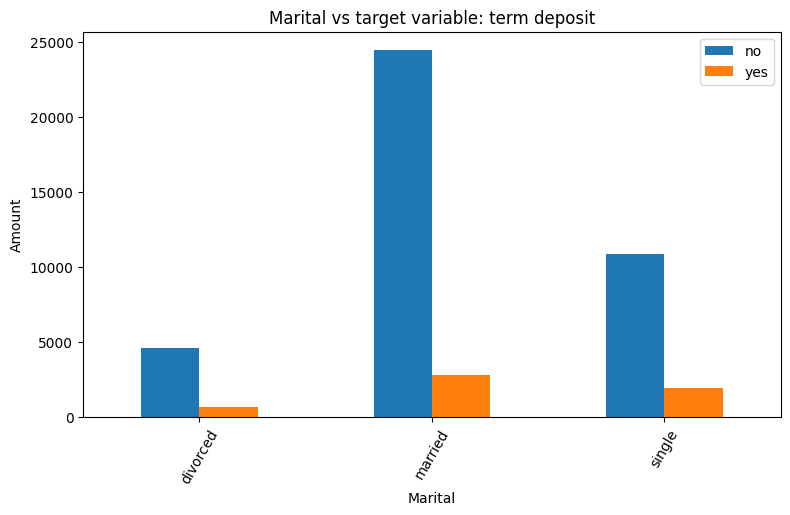

In [50]:
# Cross-tabulation between 'marital' and the target variable.
# The grouped bar chart shows how each category is distributed across 'yes' and 'no' outcomes.
cratab_marital = df01.crosstab('marital', 'y').toPandas()
cratab_marital.set_index('marital_y').plot(kind='bar', figsize=(9, 5))
plt.xlabel('Marital')
plt.ylabel('Amount')
plt.title('Marital vs target variable: term deposit')
plt.xticks(rotation=60)
plt.show()


### Analysis of `marital` vs `y`

This graph compares the target distribution across marital status groups. It is useful to observe whether the positive response is concentrated in a specific marital category.


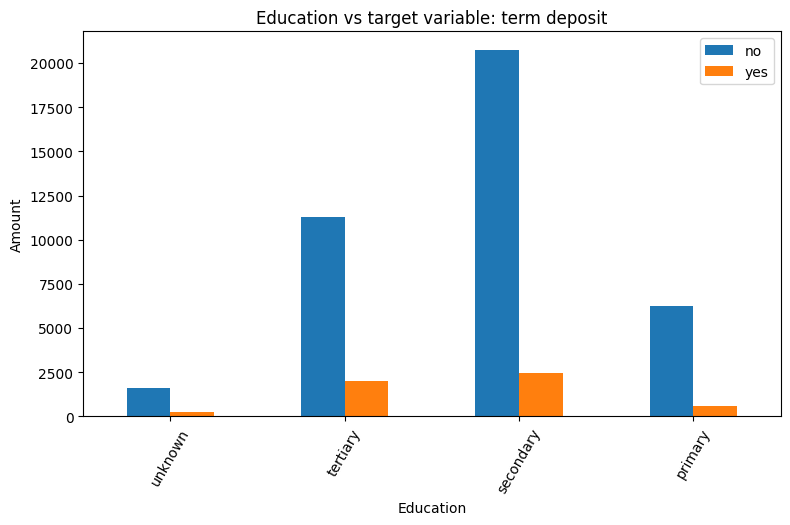

In [51]:
# Cross-tabulation between 'education' and the target variable.
# The grouped bar chart shows how each category is distributed across 'yes' and 'no' outcomes.
cratab_education = df01.crosstab('education', 'y').toPandas()
cratab_education.set_index('education_y').plot(kind='bar', figsize=(9, 5))
plt.xlabel('Education')
plt.ylabel('Amount')
plt.title('Education vs target variable: term deposit')
plt.xticks(rotation=60)
plt.show()


### Analysis of `education` vs `y`

This graph compares subscription outcomes by education level. Differences between categories may indicate that educational background contributes to the client's response.


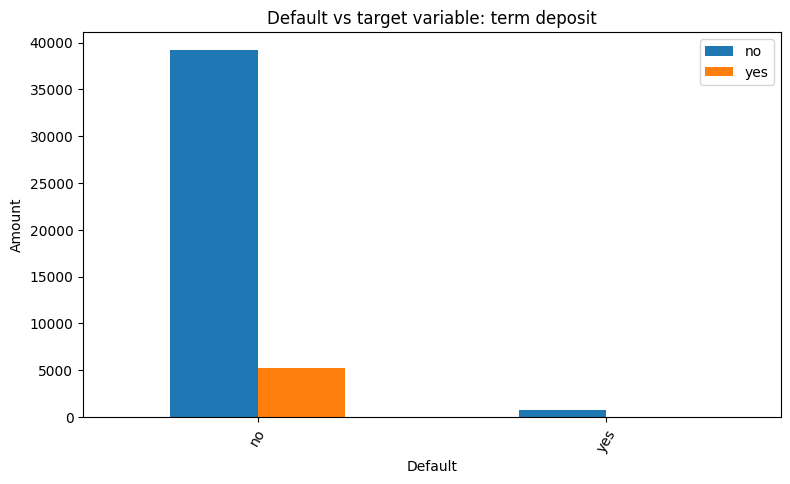

In [52]:
# Cross-tabulation between 'default' and the target variable.
# The grouped bar chart shows how each category is distributed across 'yes' and 'no' outcomes.
cratab_default = df01.crosstab('default', 'y').toPandas()
cratab_default.set_index('default_y').plot(kind='bar', figsize=(9, 5))
plt.xlabel('Default')
plt.ylabel('Amount')
plt.title('Default vs target variable: term deposit')
plt.xticks(rotation=60)
plt.show()


### Analysis of `default` vs `y`

This graph evaluates whether having credit in default is associated with lower or higher subscription outcomes. Because default cases are usually few, the comparison should focus on proportions and not only counts.


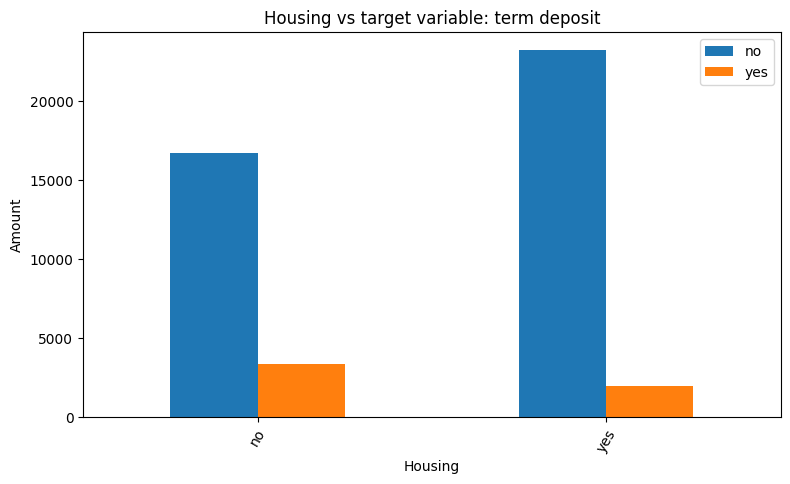

In [53]:
# Cross-tabulation between 'housing' and the target variable.
# The grouped bar chart shows how each category is distributed across 'yes' and 'no' outcomes.
cratab_housing = df01.crosstab('housing', 'y').toPandas()
cratab_housing.set_index('housing_y').plot(kind='bar', figsize=(9, 5))
plt.xlabel('Housing')
plt.ylabel('Amount')
plt.title('Housing vs target variable: term deposit')
plt.xticks(rotation=60)
plt.show()


### Analysis of `housing` vs `y`

This graph compares clients with and without housing loans. It can reveal whether housing debt is associated with lower willingness to subscribe to a term deposit.


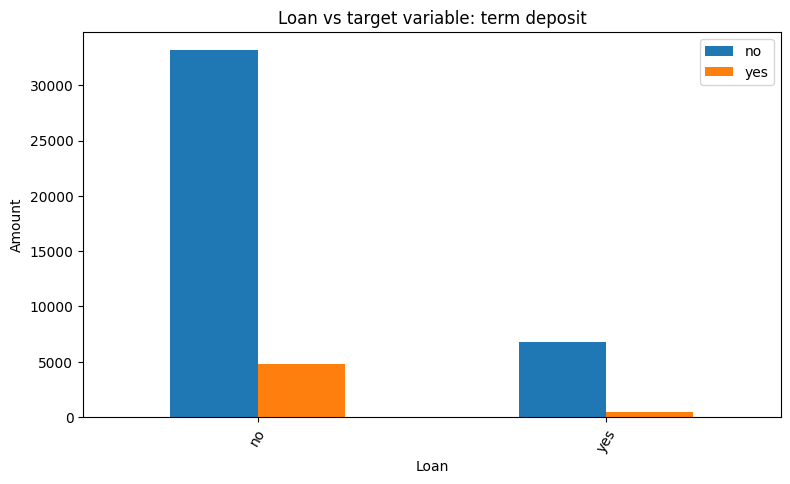

In [54]:
# Cross-tabulation between 'loan' and the target variable.
# The grouped bar chart shows how each category is distributed across 'yes' and 'no' outcomes.
cratab_loan = df01.crosstab('loan', 'y').toPandas()
cratab_loan.set_index('loan_y').plot(kind='bar', figsize=(9, 5))
plt.xlabel('Loan')
plt.ylabel('Amount')
plt.title('Loan vs target variable: term deposit')
plt.xticks(rotation=60)
plt.show()


### Analysis of `loan` vs `y`

This graph compares target outcomes according to personal loan status. A higher concentration of `no` among clients with loans may suggest financial constraint.


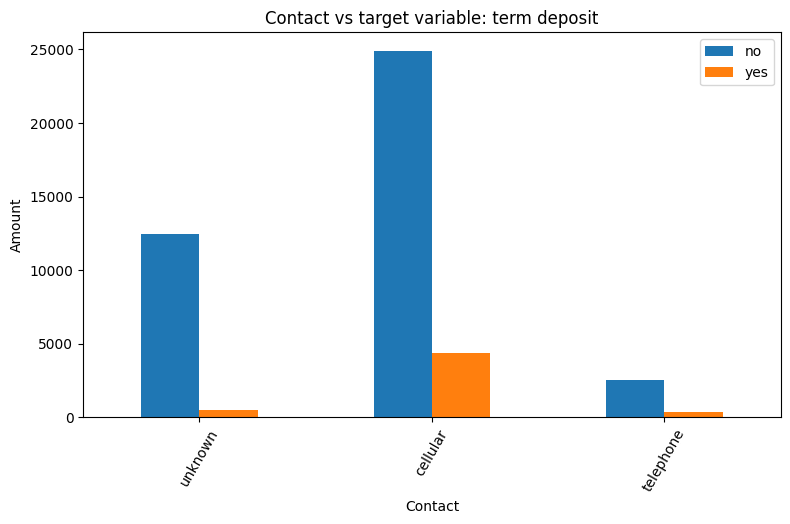

In [55]:
# Cross-tabulation between 'contact' and the target variable.
# The grouped bar chart shows how each category is distributed across 'yes' and 'no' outcomes.
cratab_contact = df01.crosstab('contact', 'y').toPandas()
cratab_contact.set_index('contact_y').plot(kind='bar', figsize=(9, 5))
plt.xlabel('Contact')
plt.ylabel('Amount')
plt.title('Contact vs target variable: term deposit')
plt.xticks(rotation=60)
plt.show()


### Analysis of `contact` vs `y`

This graph compares subscription results by communication channel. If one channel has a higher positive response, it may be more effective for the campaign.


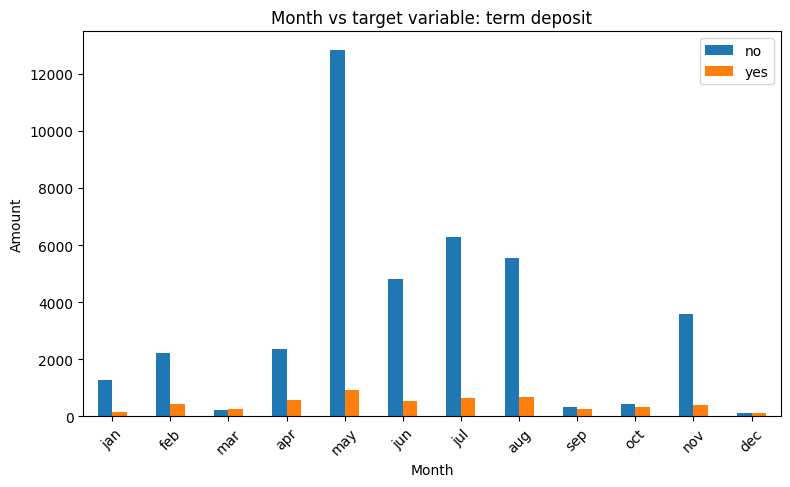

In [56]:
# Cross-tabulation between 'month' and the target variable.
# The months are displayed in chronological order.

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

cratab_month = df01.crosstab('month', 'y').toPandas()

# Rename column for easier handling
cratab_month = cratab_month.rename(columns={'month_y': 'month'})

# Convert month column to categorical with chronological order
cratab_month['month'] = pd.Categorical(
    cratab_month['month'],
    categories=month_order,
    ordered=True
)

# Sort months correctly
cratab_month = cratab_month.sort_values('month')

# Plot
cratab_month.set_index('month').plot(kind='bar', figsize=(9, 5))

plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Month vs target variable: term deposit')
plt.xticks(rotation=45)

plt.show()


### Analysis of `month` vs `y`

This graph compares the target across months. It helps identify whether campaign timing is associated with different subscription results.


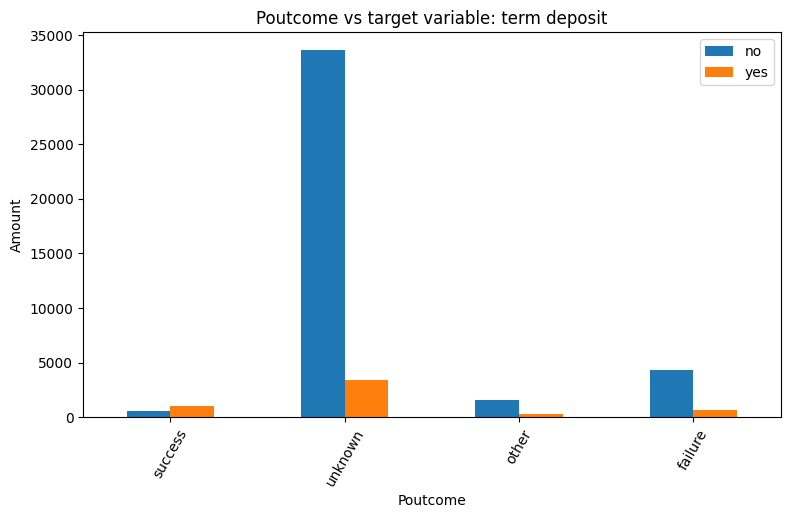

In [57]:
# Cross-tabulation between 'poutcome' and the target variable.
# The grouped bar chart shows how each category is distributed across 'yes' and 'no' outcomes.
cratab_poutcome = df01.crosstab('poutcome', 'y').toPandas()
cratab_poutcome.set_index('poutcome_y').plot(kind='bar', figsize=(9, 5))
plt.xlabel('Poutcome')
plt.ylabel('Amount')
plt.title('Poutcome vs target variable: term deposit')
plt.xticks(rotation=60)
plt.show()


### Analysis of `poutcome` vs `y`

This graph compares the current target with the previous campaign outcome. A previous success is expected to provide useful information about current subscription probability.


In [58]:
# Comparison between numerical and categorical variables.
# These graphs help analyze how numerical variables behave across categorical groups.

df01.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [59]:
# Manual list of columns in the dataset.

nomColumnas = ['age', 'job', 'marital', 'education', 'default', 'balance',
               'housing', 'loan', 'contact', 'day', 'month', 'duration',
               'campaign', 'pdays', 'previous', 'poutcome', 'y']

# Numerical columns.

colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

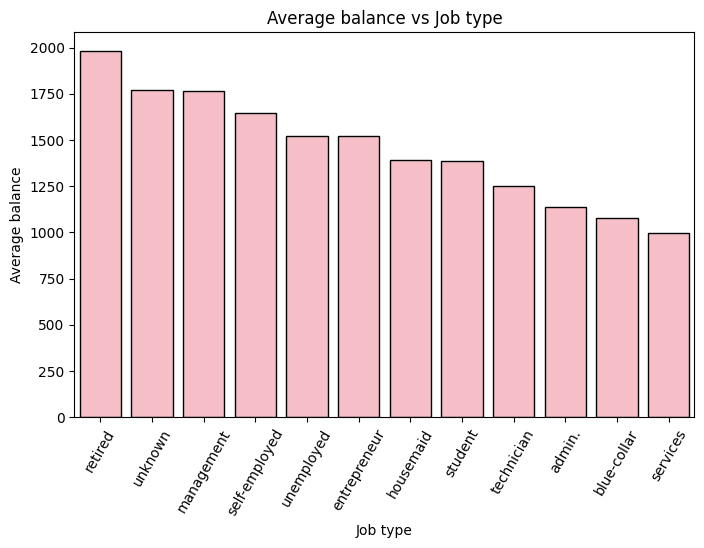

In [60]:
# Average balance by job type.
# This graph helps identify which job categories have higher or lower average balances.

montoTrabajo = df01.groupBy('job').agg({'balance':'mean'}).toPandas()
montoTrabajo = montoTrabajo.sort_values('avg(balance)', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=montoTrabajo, x='job', y='avg(balance)', color='lightpink', edgecolor='black')
plt.xlabel('Job type')
plt.ylabel('Average balance')
plt.title('Average balance vs Job type')
plt.xticks(rotation=60)
plt.show()

### Analysis:
- This graph shows the `average balance` according to each `job` category. It allows us to observe that some occupations have higher average balances than others, which suggests that the financial behavior of clients may vary depending on their type of job. This variable can be useful because the client’s occupation may be related to their economic capacity and, therefore, to their probability of subscribing.

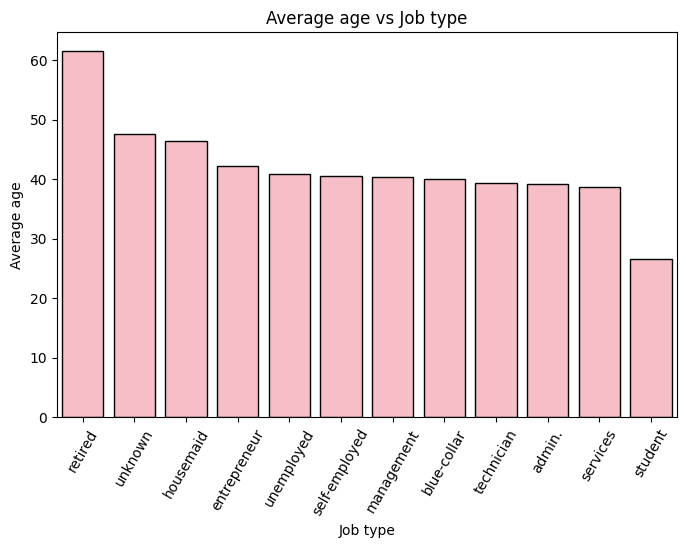

In [61]:
# Average age by job type.
# This graph helps compare the average age of clients across job categories.

edadTrabajo = df01.groupBy('job').agg({'age':'mean'}).toPandas()
edadTrabajo = edadTrabajo.sort_values('avg(age)', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=edadTrabajo, x='job', y='avg(age)', color='lightpink', edgecolor='black')
plt.xlabel('Job type')
plt.ylabel('Average age')
plt.title('Average age vs Job type')
plt.xticks(rotation=60)
plt.show()

### Analysis:
- This graph compares the `average age` of clients by `job` category. It helps identify which occupational groups are composed of older or younger clients. This is useful because `age` and `job type` together may describe different client profiles within the campaign.

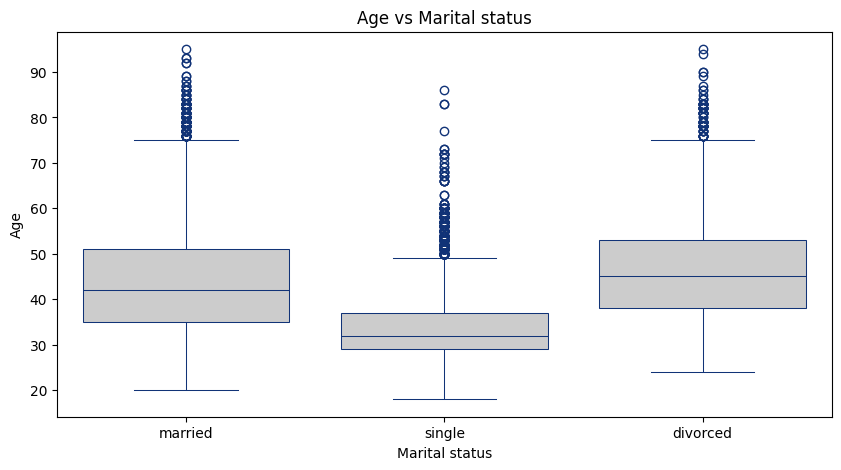

In [62]:
# Boxplot between age and marital status.
# This graph helps identify age distribution and possible outliers by marital category.

plt.figure(figsize=(10,5))
sns.boxplot(x='marital', y='age', color=".8", linecolor="#137", linewidth=0.75, data=df01.toPandas())
plt.title("Age vs Marital status")
plt.xlabel("Marital status")
plt.ylabel("Age")
plt.show()

### Analysis:
This boxplot shows how `age` is distributed according to `marital status`. Married clients tend to have higher ages, while single clients are generally younger. Some older clients appear as outliers, especially in certain marital categories.

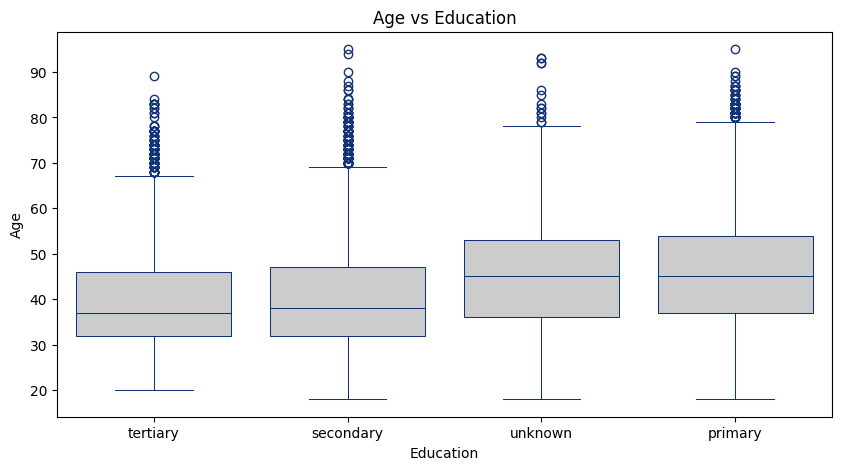

In [63]:
# Boxplot between age and education.
# This graph helps compare the age distribution across education levels.

plt.figure(figsize=(10,5))
sns.boxplot(x='education', y='age', color=".8", linecolor="#137", linewidth=0.75, data=df01.toPandas())
plt.title("Age vs Education")
plt.xlabel("Education")
plt.ylabel("Age")
plt.show()

### Analysis:
This graph compares the `age` distribution across `education levels`. It allows us to observe whether some education categories are associated with younger or older clients. In general, the graph helps identify differences in client profiles and possible outliers within each educational group.

### **15. Data quality: null values**


In [64]:
# Check the number of null values in each column.
# This step confirms whether missing values must be imputed or treated before modeling.
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} null values")


'age' : 0 null values
'job' : 0 null values
'marital' : 0 null values
'education' : 0 null values
'default' : 0 null values
'balance' : 0 null values
'housing' : 0 null values
'loan' : 0 null values
'contact' : 0 null values
'day' : 0 null values
'month' : 0 null values
'duration' : 0 null values
'campaign' : 0 null values
'pdays' : 0 null values
'previous' : 0 null values
'poutcome' : 0 null values
'y' : 0 null values


### Null-value analysis

The null-value check verifies whether the dataset contains missing values after loading and type conversion. If no null values are found, the preparation process can focus on special-coded values, class imbalance, outliers, and categorical encoding.


### **16. Special analysis of `pdays`**

- PDAYS:
    - Number of days that passed after the client was last contacted 
from a previous campaign.


In [65]:
# Count how many clients were not previously contacted.
# In this dataset, pdays = -1 means that the client was not contacted before the current campaign.
noPDAYS = df01.filter(F.col('pdays') == -1).count()
totalPDAYS = df01.count()
porcentajeNoPDAYS = noPDAYS * 100 / totalPDAYS

print(f"Number of records with pdays = -1: {noPDAYS}")
print(f"Percentage of records with pdays = -1: {porcentajeNoPDAYS:.2f}%")


Number of records with pdays = -1: 36954
Percentage of records with pdays = -1: 81.74%


### Analysis of `pdays`

The variable `pdays` contains the special value `-1`, which means that the client was not previously contacted. If this value represents a very high percentage of the dataset, the variable may be less useful in its raw form because it mixes a code for "no previous contact" with actual numerical day counts. For this reason, it is reasonable to consider dropping `pdays` or transforming it into a more interpretable indicator.


### **17. Special analysis of `previous`**

- PREVIOUS:
    - Number of contacts performed before the current campaign for this client.


In [66]:
# Review the number of previous contacts in descending order.
# This helps identify unusually high values that may behave as outliers.
df01.groupBy("previous").count().orderBy(F.desc("previous")).show()


+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



In [67]:
# Define a practical threshold for the number of previous contacts.
limitePrevio = 30

# Count records above the threshold.
cantPrevio = df01.filter(F.col('previous') > limitePrevio).count()
porcentajePrevio = cantPrevio * 100 / df01.count()

print(f"Number of records with previous > {limitePrevio}: {cantPrevio}")
print(f"Percentage of records with previous > {limitePrevio}: {porcentajePrevio:.4f}%")


Number of records with previous > 30: 12
Percentage of records with previous > 30: 0.0265%


### Analysis of `previous`

The variable `previous` may contain very high values for a small number of clients. When the number of cases above a practical threshold is very small, those records can be considered atypical because they may distort the model without representing the general behavior of the population. A threshold of 30 previous contacts is used to remove extreme cases while preserving most of the data.


### **18. Data cleaning**


In [68]:
# Remove atypical records with more than 30 previous contacts.
df02 = df01.filter(F.col('previous') <= 30)

# Drop pdays because it contains a high concentration of the special value -1.
df03 = df02.drop('pdays')

print(f"Original dataset size: {df01.count()}")
print(f"Dataset size after cleaning: {df03.count()}")


Original dataset size: 45211
Dataset size after cleaning: 45199


### Cleaning analysis

The cleaning process removes extreme values in `previous` and drops `pdays`. This keeps the dataset more consistent for modeling and avoids using a variable whose interpretation is affected by a dominant special code.


### **19. Target balancing through oversampling**

- Data balancing
    - The dependent variable presents an imbalance between the classes.
    - Most observations belong to the no category, which may bias the models. to reduce this imbalance, oversampling is applied to the minority class.
    - This helps improve the learning process and the classification performance.

In [69]:
# Separate majority and minority classes.
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')

# Count each class.
mayorConteo = dfMayorDependiente.count()
menorConteo = dfMenorDependiente.count()

print(f"Majority class count: {mayorConteo}")
print(f"Minority class count: {menorConteo}")

# Compute the oversampling ratio.
ratio = mayorConteo / menorConteo

# Oversample the minority class with replacement.
dfMenorOversampled = dfMenorDependiente.sample(withReplacement=True, fraction=ratio, seed=4321)

# Combine majority and oversampled minority class.
df04 = dfMayorDependiente.union(dfMenorOversampled)

print(f"Dataset size after oversampling: {df04.count()}")


Majority class count: 39912
Minority class count: 5287
Dataset size after oversampling: 79883


In [70]:
# Display the new target balance after oversampling.
totalNw = df04.count()
dfaux = df04.groupBy('y').count()
dfBalance = dfaux.withColumn("Percentage", dfaux["count"] * 100 / totalNw)
dfBalance.show()


+---+-----+-----------------+
|  y|count|       Percentage|
+---+-----+-----------------+
| no|39912|49.96307099132481|
|yes|39971|50.03692900867519|
+---+-----+-----------------+



### Oversampling analysis

Oversampling is applied to reduce the imbalance between the `yes` and `no` classes. This is useful because the original dataset is strongly dominated by the `no` class. By increasing the representation of the minority class, the model receives more examples of positive subscriptions and can learn patterns associated with both outcomes more fairly.


### **20. Feature encoding and vector assembly**


| Tool | Purpose |
|---|---|
| `StringIndexer` | Converts categorical labels into numerical indices. |
| `OneHotEncoder` | Converts indexed categorical variables into binary vectors to avoid imposing ordinal meaning. |
| `VectorAssembler` | Combines all encoded categorical variables and numerical variables into one `features` vector. |
| `Pipeline` | Executes all transformation stages in a reproducible sequence. |


In [71]:
# Categorical variables used for model construction.
CATEG_col = ['job', 'marital', 'education', 'default', 'month', 'housing', 'loan', 'contact', 'poutcome']

# Create an empty list to store the stages of the pipeline.
etapas = []

# For each categorical variable, create a StringIndexer and a OneHotEncoder.
for variable in CATEG_col:
    indexer = StringIndexer(inputCol=variable, outputCol=variable + '_index', handleInvalid='keep')
    encoder = OneHotEncoder(inputCols=[variable + '_index'], outputCols=[variable + '_oneHot'])
    etapas += [indexer, encoder]


In [72]:
# Create the StringIndexer for the target variable.
# The target is converted from 'yes'/'no' into a numerical label required by PySpark classifiers.
labelIndexer = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')
etapas += [labelIndexer]


In [73]:
# Numerical variables used in the model.
# pdays was removed during cleaning, so it is not included here.
NUMER_col = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']

# Input columns for the final feature vector.
entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMER_col

entradaEnsamblada


['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

In [74]:
# Assemble all predictors into one features column.
VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]


In [75]:
# Build and fit the transformation pipeline.
pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)

# Apply the fitted pipeline to the balanced dataset.
modelo = pipelineModel.transform(df04)


In [76]:
# Inspect the transformed schema and a sample of transformed records.
modelo.printSchema()
modelo.show(5)


root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- job_index: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- marital_index: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- education_index: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- default_index: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- month_index: 

In [77]:
# Create the final DataFrame for classification models.
df06 = modelo.select("label", "features")

# Inspect the first record to confirm that label and features were correctly created.
df06.first()


Row(label=0.0, features=SparseVector(50, {0: 1.0, 12: 1.0, 16: 1.0, 19: 1.0, 21: 1.0, 34: 1.0, 35: 1.0, 38: 1.0, 40: 1.0, 44: 58.0, 45: 2143.0, 46: 261.0, 47: 5.0, 48: 1.0}))

In [78]:
# Confirm the final modeling schema.
df06.printSchema()


root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



### Encoding analysis

The categorical variables are transformed into numerical representations using `StringIndexer` and `OneHotEncoder`. This is necessary because classification algorithms require numerical input. The final `features` column contains both the encoded categorical variables and the numerical predictors, allowing the models to train on a single vector representation.


### **21. Train-test split**

    - The dataset is divided into training and testing sets using an 80% - 20% proportion.
    - The training set is used to fit the models, while the test set is used to evaluate their performance.
    - The balance of the target variable is verified after the split to ensure a fair distribution between classes.
- Classification models to evaluate
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - Gradient Boosted Tree (GBT)
    - Support Vector Machine (SVM)
    - Multilayer Perceptron Classifier (MLP)

  | Metric | Description |
|---|---|
| `Confusion Matrix` | Summarizes the number of correct and incorrect predictions for each class. |
| `Accuracy` | Measures the proportion of correct predictions over the total observations.|
| `Precision` | Measures how many predicted positive cases are actually positive.|
| `Recall` | Measures how many real positive cases are correctly identified by the model. |
| `F1-score` | Combines precision and recall into a single performance metric. |
| `ROC-AUC` | Evaluates the ability of the model to distinguish between the classes.|


In [79]:
# Split the dataset into 80% training and 20% testing.
trainData, testData = df06.randomSplit([0.8, 0.2], seed=4321)

print(f"Training set size: {trainData.count()}")
print(f"Testing set size: {testData.count()}")


Training set size: 63983


[Stage 347:============================>                            (2 + 2) / 4]

Testing set size: 15900


In [80]:
# Check class balance in the training set.
distroTrain = trainData.groupBy("label").count()
distroTrain = distroTrain.withColumn("Percentage", distroTrain["count"] * 100 / trainData.count())
distroTrain.show()


[Stage 353:==========================================>              (3 + 1) / 4]

+-----+-----+------------------+
|label|count|        Percentage|
+-----+-----+------------------+
|  0.0|31880|49.825734960848976|
|  1.0|32103|50.174265039151024|
+-----+-----+------------------+



In [81]:
# Check class balance in the testing set.
distroTest = testData.groupBy("label").count()
distroTest = distroTest.withColumn("Percentage", distroTest["count"] * 100 / testData.count())
distroTest.show()


[Stage 359:==========================================>              (3 + 1) / 4]

+-----+-----+------------------+
|label|count|        Percentage|
+-----+-----+------------------+
|  0.0| 8032|50.515723270440255|
|  1.0| 7868|49.484276729559745|
+-----+-----+------------------+



### Train-test split analysis

The data is divided into training and testing sets to evaluate whether the models generalize to data not used during training. The balance check confirms whether the oversampled distribution remains reasonably similar in both subsets.


### **22. Evaluation functions**


In [82]:
# Function to plot a confusion matrix from a Spark DataFrame.
def plotMatConfusion(confMatrix, subtitulo):
    confMatrixPandas = confMatrix.toPandas()
    matriz = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0)

    plt.figure(figsize=(5, 4))
    sns.heatmap(matriz, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - ' + subtitulo)
    plt.xlabel('Prediction')
    plt.ylabel('Actual label')
    plt.show()


In [83]:
# Function to plot ROC curves for classification models.
# It works with models that have probability or rawPrediction columns.

def plotROC(predictions, rocMetric, subtitulo):

    # Check if the model contains probability column
    if 'probability' in predictions.columns:

        probs = predictions.select('probability', 'label').toPandas()
        probs['prob_yes'] = probs['probability'].apply(lambda x: float(x[1]))

    else:
        # Used for SVM models
        probs = predictions.select('rawPrediction', 'label').toPandas()
        probs['prob_yes'] = probs['rawPrediction'].apply(lambda x: float(x[1]))

    fpr, tpr, thresholds = roc_curve(probs['label'], probs['prob_yes'])

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {rocMetric:.4f})')
    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {subtitulo}')
    plt.legend(loc='lower right')

    plt.show()

### **23. First model: Logistic Regression**


Logistic Regression is a linear classification technique that estimates the probability of belonging to a class using a logistic function. It is commonly used as a baseline model because of its interpretability and stable performance.

##### - **Create the Logistic Regression classifier.**

In [84]:
instanceLR = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)

# Train the Logistic Regression model with the training data.
modelLR = instanceLR.fit(trainData)


26/05/24 04:14:05 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

##### - **Generate predictions on the testing data.**

In [85]:
predLR = modelLR.transform(testData)

# Display a sample of predictions, probabilities, and actual labels.
predLR.select("label", "prediction", "probability").show(10, truncate=False)


[Stage 374:>                                                        (0 + 1) / 1]

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.7835470228497695,0.21645297715023049]|
|0.0  |0.0       |[0.7518052592510014,0.2481947407489986] |
|0.0  |0.0       |[0.8075658354545361,0.19243416454546391]|
|0.0  |0.0       |[0.924470953845149,0.07552904615485101] |
|0.0  |0.0       |[0.9136230292321379,0.0863769707678621] |
|0.0  |0.0       |[0.918176662121451,0.08182333787854901] |
|0.0  |0.0       |[0.911764064373494,0.088235935626506]   |
|0.0  |0.0       |[0.8835336702788389,0.11646632972116111]|
|0.0  |0.0       |[0.6345014810658964,0.36549851893410357]|
|0.0  |0.0       |[0.8745555353607058,0.12544446463929415]|
+-----+----------+----------------------------------------+
only showing top 10 rows



##### - **Create a multiclass evaluator to compute classification metrics.**

In [86]:
evaluaLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Compute performance metrics.
accuracyLR = evaluaLR.evaluate(predLR, {evaluaLR.metricName: "accuracy"})
f1ScoreLR = evaluaLR.evaluate(predLR, {evaluaLR.metricName: "f1"})
precisionLR = evaluaLR.evaluate(predLR, {evaluaLR.metricName: "weightedPrecision"})
recallLR = evaluaLR.evaluate(predLR, {evaluaLR.metricName: "weightedRecall"})

print(f"Logistic Regression Accuracy: {accuracyLR:.4f}")
print(f"Logistic Regression F1-score: {f1ScoreLR:.4f}")
print(f"Logistic Regression Precision: {precisionLR:.4f}")
print(f"Logistic Regression Recall: {recallLR:.4f}")


[Stage 381:============================>                            (2 + 2) / 4]

Logistic Regression Accuracy: 0.8358
Logistic Regression F1-score: 0.8358
Logistic Regression Precision: 0.8360
Logistic Regression Recall: 0.8358


#### Logistic Regression analysis

- The Logistic Regression model achieved an accuracy of approximately 83.6%, showing good overall classification performance.

- The precision (83.6%) and recall (83.5) values, indicating that the model correctly identifies most positive cases while maintaining a relatively low number of incorrect positive predictions.

- The F1-score also remains balanced, suggesting stable performance between precision and recall.

##### - **Confusion matrix for Logistic Regression.**

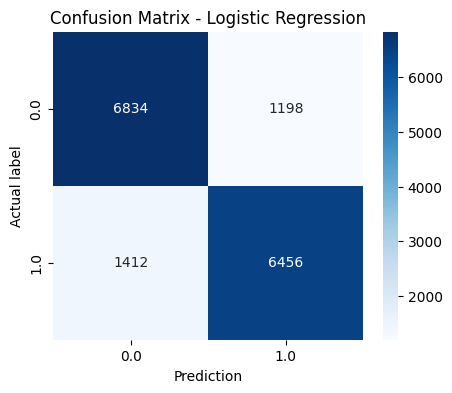

In [87]:
# Build and plot the confusion matrix for Logistic Regression.
firstModel = "Logistic Regression"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, firstModel)


#### Confusion Matrix interpretation

- The confusion matrix shows that:

    - 6834 clients were correctly classified as non-subscribers (true negatives).
    - 6456 clients were correctly classified as subscribers (true positives).
    - 1198 clients were incorrectly classified as subscribers when they were not (false positives).
    - 1412 clients were incorrectly classified as non-subscribers when they actually subscribed (false negatives).

- This indicates that the model generates slightly more false negatives than false positives. From a business perspective, false negatives may be more critical because potential clients who would subscribe are being missed by the campaign.

- However, the difference between both types of errors is not excessively large, suggesting that the model maintains a relatively balanced classification behavior.

##### - **ROC area for Logistic Regression.**

Logistic Regression ROC AUC: 0.9113


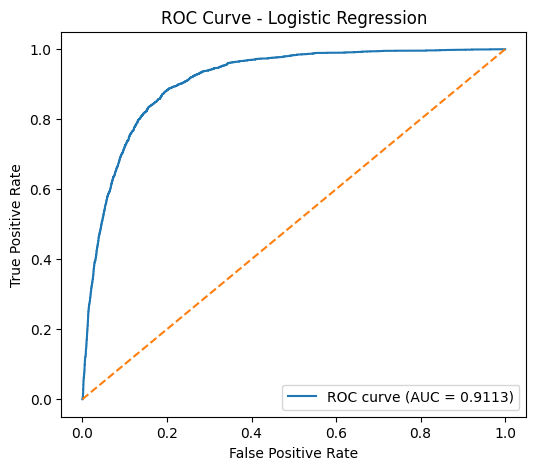

In [88]:
# Build and plot the confusion matrix for Logistic Regression.
evaluaBinLR = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
rocLR = evaluaBinLR.evaluate(predLR)

print(f"Logistic Regression ROC AUC: {rocLR:.4f}")
plotROC(predLR, rocLR, firstModel)


#### ROC Curve interpretation

- The ROC AUC value of approximately 0.9114 indicates an excellent discrimination capacity between the two classes. Since the ROC curve remains far above the diagonal reference line, the model is capable of distinguishing subscribers from non-subscribers with high effectiveness.

- An AUC above 0.90 generally reflects a strong classification model, meaning that Logistic Regression performs very well despite being one of the simplest models evaluated.

##### Overfitting analysis

- No strong evidence of overfitting is observed. The model maintains balanced performance across the evaluation metrics, suggesting good generalization capability.

### **24. Second model: Decision Tree**


Decision Tree is a classification technique that separates the data through a sequence of decision rules. It is easy to interpret and can capture nonlinear relationships between variables.

##### - **Create the Logistic Regression classifier.**

In [89]:
instanceDT = DecisionTreeClassifier(labelCol='label', featuresCol='features', seed=4321)

# Train the Decision Tree model with the training data.
modelDT = instanceDT.fit(trainData)

##### - **Generate predictions on the testing data.**

In [90]:
predDT = modelDT.transform(testData)

# Display a sample of predictions, probabilities, and actual labels.
predDT.select("label", "prediction", "probability").show(10, truncate=False)


[Stage 412:>                                                        (0 + 1) / 1]

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.8301335028607756,0.16986649713922441]|
|0.0  |0.0       |[0.8301335028607756,0.16986649713922441]|
|0.0  |0.0       |[0.9400127632418634,0.05998723675813657]|
|0.0  |0.0       |[0.9400127632418634,0.05998723675813657]|
|0.0  |0.0       |[0.9400127632418634,0.05998723675813657]|
|0.0  |0.0       |[0.8301335028607756,0.16986649713922441]|
|0.0  |0.0       |[0.8301335028607756,0.16986649713922441]|
|0.0  |0.0       |[0.8301335028607756,0.16986649713922441]|
|0.0  |0.0       |[0.5882976842849567,0.4117023157150433] |
|0.0  |0.0       |[0.8301335028607756,0.16986649713922441]|
+-----+----------+----------------------------------------+
only showing top 10 rows



##### - **Create a multiclass evaluator to compute classification metrics.**

In [91]:
evaluaDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Compute performance metrics.
accuracyDT = evaluaDT.evaluate(predDT, {evaluaDT.metricName: "accuracy"})
f1ScoreDT = evaluaDT.evaluate(predDT, {evaluaDT.metricName: "f1"})
precisionDT = evaluaDT.evaluate(predDT, {evaluaDT.metricName: "weightedPrecision"})
recallDT = evaluaDT.evaluate(predDT, {evaluaDT.metricName: "weightedRecall"})

print(f"Decision Tree Accuracy: {accuracyDT:.4f}")
print(f"Decision Tree F1-score: {f1ScoreDT:.4f}")
print(f"Decision Tree Precision: {precisionDT:.4f}")
print(f"Decision Tree Recall: {recallDT:.4f}")


[Stage 419:==========================================>              (3 + 1) / 4]

Decision Tree Accuracy: 0.8063
Decision Tree F1-score: 0.8062
Decision Tree Precision: 0.8066
Decision Tree Recall: 0.8063


#### Decision Tree analysis

- The Decision Tree model achieved an accuracy close to 80.6%, indicating acceptable overall classification performance.

- The precision, recall, and F1-score are also around 80%, showing relatively balanced behavior between identifying positive cases and avoiding incorrect classifications.

##### - **Confusion matrix for Decision Tree.**

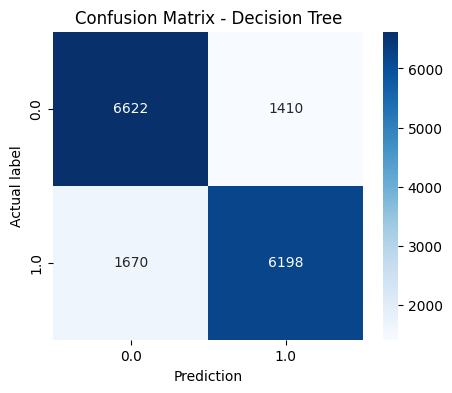

In [92]:
# Build and plot the confusion matrix for Decision Tree.
secondModel = "Decision Tree"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, secondModel)


#### Confusion Matrix interpretation

- The confusion matrix shows that:

    - 6622 clients were correctly classified as non-subscribers (true negatives).
    - 6198 clients were correctly classified as subscribers (true positives).
    - 1410 clients were incorrectly classified as subscribers when they were not (false positives).
    - 1670 clients were incorrectly classified as non-subscribers when they actually subscribed (false negatives).

- This indicates that the model produces more false negatives than false positives. Therefore, some clients who would actually subscribe are being classified as non-subscribers, which may reduce the effectiveness of the marketing campaign.

- Even though the model correctly classifies a large number of observations, the number of classification errors is still considerable, especially for positive cases

##### - **ROC area for Decision Tree.**

Decision Tree ROC AUC: 0.6082


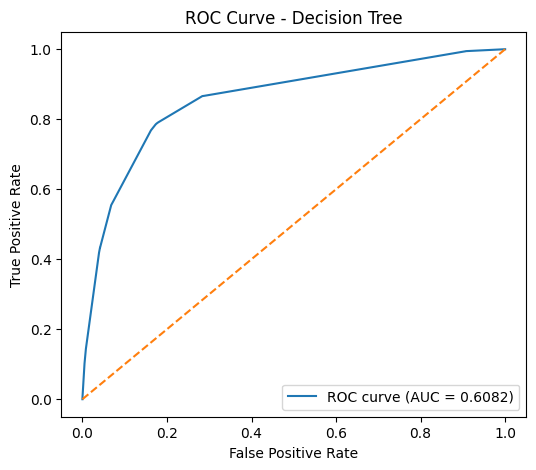

In [93]:
# Build and plot the confusion matrix for Decision Tree.
evaluaBinDT = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
rocDT = evaluaBinDT.evaluate(predDT)

print(f"Decision Tree ROC AUC: {rocDT:.4f}")
plotROC(predDT, rocDT, secondModel)


#### ROC Curve interpretation

- The ROC AUC value of approximately 0.6082 indicates a limited discrimination capacity between the classes. Although the ROC curve remains above the diagonal reference line, the separation between subscribers and non-subscribers is weak.

- An AUC close to 0.60 suggests that the model has difficulties distinguishing the classes correctly and may not generalize as effectively when predicting new observations.

##### Overfitting analysis

- No severe overfitting is observed, although the relatively low ROC AUC suggests that the model may be underfitting and failing to capture more complex relationships in the data.

### **25. Third model: Random Forest**

Random Forest is an ensemble learning method that combines multiple decision trees to improve stability and reduce overfitting. Predictions are obtained from the aggregation of several trees.

##### - **Create the Random Forest classifier.**

In [94]:
# Create and train the Random Forest model.
instanceRF = RandomForestClassifier(labelCol='label', featuresCol='features', numTrees=50, seed=123)

modelRF = instanceRF.fit(trainData)

##### - **Generate predictions on the testing data.**

In [95]:
# Generate predictions using Random Forest.
predRF = modelRF.transform(testData)

predRF.select('label', 'prediction', 'probability').show(10, truncate=False)

[Stage 450:>                                                        (0 + 1) / 1]

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.6225668449754622,0.3774331550245378] |
|0.0  |1.0       |[0.47752283369566556,0.5224771663043345]|
|0.0  |0.0       |[0.653371352543007,0.3466286474569929]  |
|0.0  |0.0       |[0.7314092459864997,0.26859075401350024]|
|0.0  |0.0       |[0.723341927978725,0.2766580720212751]  |
|0.0  |0.0       |[0.7097133312786529,0.29028666872134723]|
|0.0  |0.0       |[0.7137975816364746,0.2862024183635255] |
|0.0  |0.0       |[0.710673089056233,0.289326910943767]   |
|0.0  |0.0       |[0.508256174551621,0.491743825448379]   |
|0.0  |0.0       |[0.6905135523502958,0.30948644764970423]|
+-----+----------+----------------------------------------+
only showing top 10 rows



##### - **Evaluate Random Forest metrics.**

In [96]:
# Evaluate Random Forest performance metrics.
evaluaRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracyRF = evaluaRF.evaluate(predRF, {evaluaRF.metricName: "accuracy"})
precisionRF = evaluaRF.evaluate(predRF, {evaluaRF.metricName: "weightedPrecision"})
recallRF = evaluaRF.evaluate(predRF, {evaluaRF.metricName: "weightedRecall"})
f1RF = evaluaRF.evaluate(predRF, {evaluaRF.metricName: "f1"})

print("Accuracy:", accuracyRF)
print("Precision:", precisionRF)
print("Recall:", recallRF)
print("F1-score:", f1RF)

[Stage 457:==========================================>              (3 + 1) / 4]

Accuracy: 0.8267295597484277
Precision: 0.83088817030534
Recall: 0.8267295597484277
F1-score: 0.8263066698374482


#### Random Forest analysis

- The Random Forest model achieved an accuracy close to 82.7%, indicating good overall classification performance.

- The precision is approximately 83.1%, meaning that most predicted positive cases are classified correctly. Additionally, the recall remains close to 82.7%, showing that the model identifies a high proportion of the real subscribers.

- The F1-score is also balanced, suggesting stable performance between precision and recall.

##### - **Confusion matrix for Random Forest.**

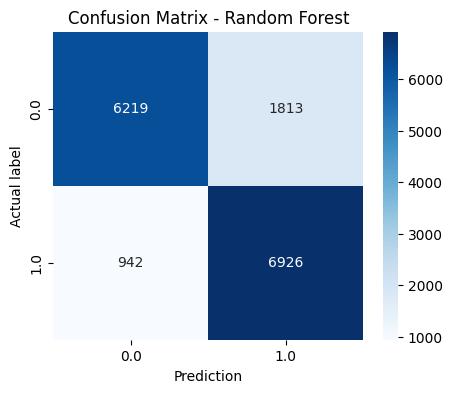

In [97]:
# Build and plot the confusion matrix for Random Forest.
thirdModel = "Random Forest"

confMatrixRF = predRF.groupBy("label", "prediction").count()

plotMatConfusion(confMatrixRF, thirdModel)

#### Confusion Matrix interpretation

- The confusion matrix shows that:

    - 6219 clients were correctly classified as non-subscribers (true negatives).
    - 6926 clients were correctly classified as subscribers (true positives).
    - 1813 clients were incorrectly classified as subscribers when they were not (false positives).
    - 942 clients were incorrectly classified as non-subscribers when they actually subscribed (false negatives).

- This indicates that the model produces fewer false negatives than false positives. From a business perspective, this behavior may be favorable because the model is missing fewer potential subscribers.

- However, the larger number of false positives means that some clients who are not interested may still be targeted by the campaign.

- Overall, the model shows strong ability to identify positive cases correctly.

##### - **ROC area for Random Forest.**

ROC-AUC: 0.8941817329689883


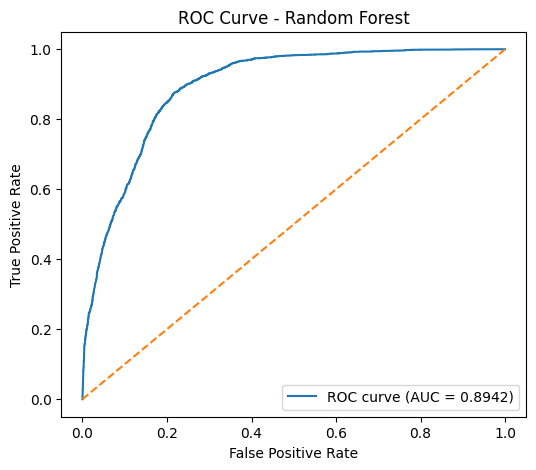

In [98]:
# Build and plot the confusion matrix for Random Forest.
evaluaBinRF = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")

aucRF = evaluaBinRF.evaluate(predRF)

print("ROC-AUC:", aucRF)

plotROC(predRF, aucRF, thirdModel)

#### ROC Curve interpretation

- The ROC AUC value of approximately 0.8942 indicates very good discrimination capacity between the classes. The ROC curve remains considerably above the diagonal reference line, showing that the model can effectively separate subscribers from non-subscribers.

- Although the AUC is slightly below 0.90, the model still demonstrates strong predictive capability and reliable classification performance.

##### Overfitting analysis

- No strong evidence of overfitting is observed. The metrics remain relatively balanced, suggesting that the model generalizes adequately without excessively memorizing the training data.

### **26. Fourth model: Gradient Boosted Tree (GBT)**

Gradient Boosted Tree (GBT) is an ensemble technique that builds trees sequentially, where each new tree attempts to correct the errors of the previous ones. It usually achieves strong predictive performance.

##### - **Create the GBT classifier.**

In [99]:
# Create and train the Gradient Boosted Tree model.
instanceGBT = GBTClassifier(labelCol='label', featuresCol='features', maxIter=20, seed=123)

modelGBT = instanceGBT.fit(trainData)

##### - **Generate predictions on the testing data.**

In [100]:
# Generate predictions using GBT.
predGBT = modelGBT.transform(testData)

predGBT.select('label', 'prediction', 'probability').show(10, truncate=False)

[Stage 678:>                                                        (0 + 1) / 1]

+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0.0  |0.0       |[0.776744768323671,0.223255231676329]    |
|0.0  |0.0       |[0.9093734790047845,0.09062652099521551] |
|0.0  |0.0       |[0.9142008383385377,0.08579916166146229] |
|0.0  |0.0       |[0.9464828692096175,0.05351713079038245] |
|0.0  |0.0       |[0.9492256625950372,0.050774337404962844]|
|0.0  |0.0       |[0.9044765723807905,0.09552342761920951] |
|0.0  |0.0       |[0.9249564357411196,0.07504356425888037] |
|0.0  |0.0       |[0.9157692973610643,0.08423070263893573] |
|0.0  |0.0       |[0.6874893058543138,0.3125106941456862]  |
|0.0  |0.0       |[0.9159531955026315,0.08404680449736845] |
+-----+----------+-----------------------------------------+
only showing top 10 rows



##### - **Evaluate GBT metrics.**

In [101]:
# Evaluate GBT performance metrics.
evaluaGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracyGBT = evaluaGBT.evaluate(predGBT, {evaluaGBT.metricName: "accuracy"})
precisionGBT = evaluaGBT.evaluate(predGBT, {evaluaGBT.metricName: "weightedPrecision"})
recallGBT = evaluaGBT.evaluate(predGBT, {evaluaGBT.metricName: "weightedRecall"})
f1GBT = evaluaGBT.evaluate(predGBT, {evaluaGBT.metricName: "f1"})

print("Accuracy:", accuracyGBT)
print("Precision:", precisionGBT)
print("Recall:", recallGBT)
print("F1-score:", f1GBT)

[Stage 685:==========================================>              (3 + 1) / 4]

Accuracy: 0.8580503144654088
Precision: 0.8598522766823498
Recall: 0.8580503144654088
F1-score: 0.8579326139534054


#### Gradient Boosted Tree (GBT) analysis

- The GBT model achieved an accuracy close to 85.8%, indicating strong overall classification performance.

- The precision is approximately 86.0%, meaning that most predicted positive cases are classified correctly. Additionally, the recall remains close to 85.8%, showing that the model correctly identifies a high proportion of the real subscribers.

- The F1-score is also balanced, reflecting stable performance between precision and recall.

##### - **Confusion matrix for GBT.**

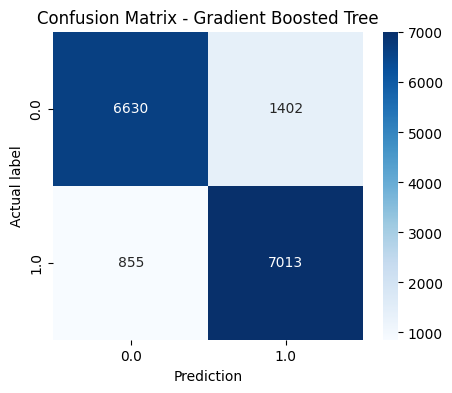

In [102]:
# Build and plot the confusion matrix for GBT.
fourthModel = "Gradient Boosted Tree"

confMatrixGBT = predGBT.groupBy("label", "prediction").count()

plotMatConfusion(confMatrixGBT, fourthModel)

#### Confusion Matrix interpretation

- The confusion matrix shows that:

    - 6630 clients were correctly classified as non-subscribers (true negatives).
    - 7013 clients were correctly classified as subscribers (true positives).
    - 1402 clients were incorrectly classified as subscribers when they were not (false positives).
    - 855 clients were incorrectly classified as non-subscribers when they actually subscribed (false negatives).

- This indicates that the model generates fewer false negatives than false positives. From a business perspective, this is beneficial because fewer potential subscribers are being missed by the campaign.

- Additionally, the number of true positives is considerably high, showing that the model performs especially well when identifying clients who are likely to subscribe.

##### - **ROC area for GBT.**

ROC-AUC: 0.9278756621328615


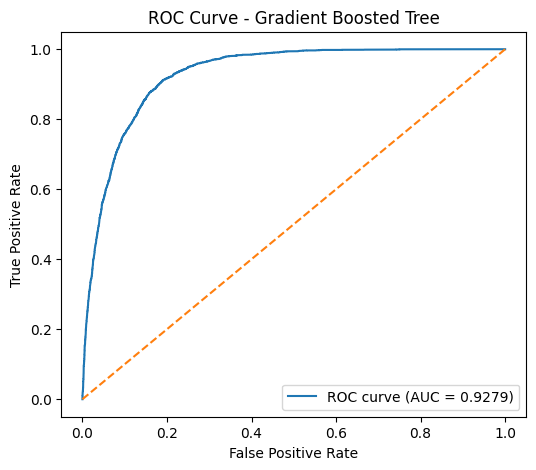

In [103]:
# Build and plot the confusion matrix for GBT.
evaluaBinGBT = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")

aucGBT = evaluaBinGBT.evaluate(predGBT)

print("ROC-AUC:", aucGBT)

plotROC(predGBT, aucGBT, fourthModel)

#### ROC Curve interpretation

- The ROC AUC value of approximately 0.9279 indicates excellent discrimination capacity between the classes. The ROC curve stays far above the diagonal reference line, demonstrating that the model separates subscribers from non-subscribers very effectively.

- An AUC above 0.92 reflects a very strong classification model with high predictive capability.

##### Overfitting analysis

- No strong evidence of overfitting is observed. The model maintains balanced metrics and strong ROC performance, suggesting good generalization ability on unseen data.

### **27. Fifth model: Support Vector Machine (SVM)**

Support Vector Machine (SVM) is a classification technique that searches for the optimal boundary separating the classes. It performs well in high-dimensional classification problems.

##### - **Create the SVM classifier.**

In [104]:
# Create and train the Support Vector Machine model.
instanceSVM = LinearSVC(labelCol='label', featuresCol='features', maxIter=20)

modelSVM = instanceSVM.fit(trainData)

##### - **Generate predictions on the testing data.**

In [105]:
# Generate predictions using SVM.
predSVM = modelSVM.transform(testData)

predSVM.select('label', 'prediction', 'rawPrediction').show(10, truncate=False)

[Stage 747:>                                                        (0 + 1) / 1]

+-----+----------+------------------------------------------+
|label|prediction|rawPrediction                             |
+-----+----------+------------------------------------------+
|0.0  |0.0       |[0.9178943780985346,-0.9178943780985346]  |
|0.0  |0.0       |[0.8202671165795498,-0.8202671165795498]  |
|0.0  |0.0       |[0.9565945724783645,-0.9565945724783645]  |
|0.0  |0.0       |[1.755898548498252,-1.755898548498252]    |
|0.0  |0.0       |[1.5481114938361582,-1.5481114938361582]  |
|0.0  |0.0       |[1.6627253587701785,-1.6627253587701785]  |
|0.0  |0.0       |[1.626739599170401,-1.626739599170401]    |
|0.0  |0.0       |[1.4235908321692297,-1.4235908321692297]  |
|0.0  |0.0       |[0.29947125885219616,-0.29947125885219616]|
|0.0  |0.0       |[1.4047147350666658,-1.4047147350666658]  |
+-----+----------+------------------------------------------+
only showing top 10 rows



##### - **Evaluate SVM metrics.**

In [106]:
# Evaluate SVM performance metrics.
evaluaSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracySVM = evaluaSVM.evaluate(predSVM, {evaluaSVM.metricName: "accuracy"})
precisionSVM = evaluaSVM.evaluate(predSVM, {evaluaSVM.metricName: "weightedPrecision"})
recallSVM = evaluaSVM.evaluate(predSVM, {evaluaSVM.metricName: "weightedRecall"})
f1SVM = evaluaSVM.evaluate(predSVM, {evaluaSVM.metricName: "f1"})

print("Accuracy:", accuracySVM)
print("Precision:", precisionSVM)
print("Recall:", recallSVM)
print("F1-score:", f1SVM)

[Stage 754:==========================================>              (3 + 1) / 4]

Accuracy: 0.8380503144654088
Precision: 0.8380492051148647
Recall: 0.8380503144654088
F1-score: 0.8380461492957092


#### Support Vector Machine (SVM) analysis

- The SVM model achieved an accuracy close to 83.8%, indicating good overall classification performance.

- The precision is approximately 83.0%, while the recall remains close to 83.8%, showing that the model correctly identifies a large proportion of the positive cases.

- The F1-score is also balanced, suggesting stable behavior between precision and recall.

##### - **Confusion matrix for SVM.**

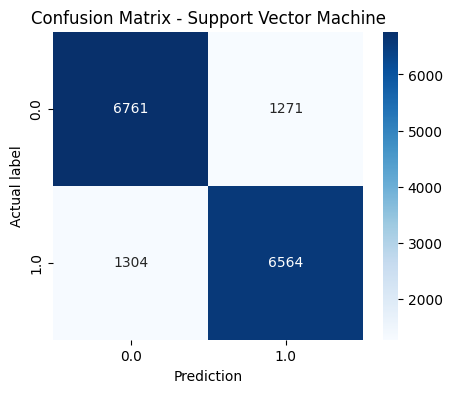

In [107]:
# Build and plot the confusion matrix for SVM.
fifthModel = "Support Vector Machine"

confMatrixSVM = predSVM.groupBy("label", "prediction").count()

plotMatConfusion(confMatrixSVM, fifthModel)

#### Confusion Matrix interpretation

- The confusion matrix shows that:

    - 6761 clients were correctly classified as non-subscribers (true negatives).
    - 6564 clients were correctly classified as subscribers (true positives).
    - 1271 clients were incorrectly classified as subscribers when they were not (false positives).
    - 1304 clients were incorrectly classified as non-subscribers when they actually subscribed (false negatives).

- This indicates that the model maintains a relatively balanced number of false positives and false negatives. The classification errors are moderate, while the number of correctly classified observations remains considerably high.

- From a business perspective, the model performs adequately because it is capable of identifying many potential subscribers without generating an excessively large number of incorrect positive predictions.

##### - **ROC area for SVM.**

ROC-AUC: 0.9114287559345738


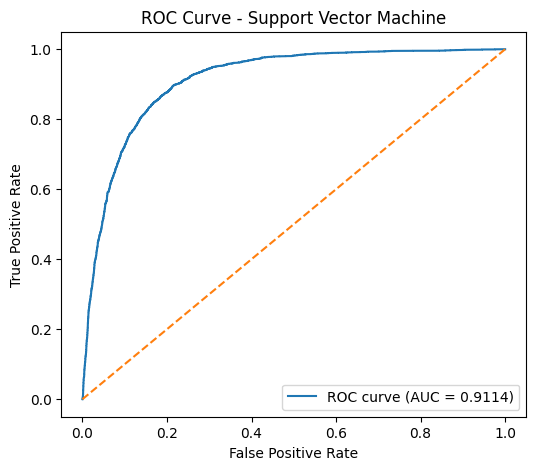

In [108]:
# Build and plot the confusion matrix for SVM.
evaluaBinSVM = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")

aucSVM = evaluaBinSVM.evaluate(predSVM)

print("ROC-AUC:", aucSVM)

plotROC(predSVM, aucSVM, fifthModel)

#### ROC Curve interpretation

- The ROC AUC value of approximately 0.9114 indicates excellent discrimination capacity between the classes. The ROC curve remains clearly above the diagonal reference line, demonstrating that the model distinguishes subscribers from non-subscribers effectively.

- An AUC above 0.90 suggests that SVM has strong predictive capability and reliable classification performance.

##### Overfitting analysis

- No strong evidence of overfitting is observed. The metrics remain balanced, suggesting that the model generalizes appropriately to unseen observations.

### **28. Sixth model: Multilayer Perceptron Classifier (MLP)**

Multilayer Perceptron is a neural network classification technique. It uses connected layers of neurons to learn nonlinear relationships between the input variables and the target class. In this case, it is useful as an additional model because it can capture more complex patterns than a simple linear classifier.

##### - **Create the Multilayer Perceptron classifier.**

In [109]:
# Obtain the number of input features from the assembled features vector.
# This value is needed to define the first layer of the neural network.
numFeaturesMLP = trainData.select("features").first()["features"].size

# Define the architecture of the neural network.
# The first layer receives all input features and the last layer has 2 neurons because this is a binary classification problem.
layersMLP = [numFeaturesMLP, 20, 10, 2]

# Create the Multilayer Perceptron classifier.
# maxIter controls the maximum number of training iterations.
instanceMLP = MultilayerPerceptronClassifier(
    labelCol='label',
    featuresCol='features',
    layers=layersMLP,
    maxIter=100,
    blockSize=128,
    seed=123
)

# Train the MLP model with the training data.
modelMLP = instanceMLP.fit(trainData)

##### - **Generate predictions on the testing data.**

In [110]:
# Generate predictions using the trained MLP model.
predMLP = modelMLP.transform(testData)

# Display a sample of actual labels, predicted labels, and probabilities.
predMLP.select("label", "prediction", "probability").show(10, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0.0  |0.0       |[0.7797901481998398,0.22020985180016023]|
|0.0  |0.0       |[0.8247563319177069,0.17524366808229294]|
|0.0  |1.0       |[0.3197776435627262,0.6802223564372738] |
|0.0  |1.0       |[0.47131364137426224,0.5286863586257378]|
|0.0  |1.0       |[0.47330757448824523,0.5266924255117548]|
|0.0  |0.0       |[0.8436700723650432,0.15632992763495676]|
|0.0  |0.0       |[0.8843669625987248,0.11563303740127519]|
|0.0  |0.0       |[0.8619980781597681,0.1380019218402318] |
|0.0  |1.0       |[0.3197776436049857,0.6802223563950144] |
|0.0  |0.0       |[0.8803892312257975,0.11961076877420243]|
+-----+----------+----------------------------------------+
only showing top 10 rows



##### - **Evaluate MLP metrics.**

In [111]:
# Create a multiclass evaluator to calculate the main classification metrics.
evaluaMLP = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Compute performance metrics for the MLP model.
accuracyMLP = evaluaMLP.evaluate(predMLP, {evaluaMLP.metricName: "accuracy"})
precisionMLP = evaluaMLP.evaluate(predMLP, {evaluaMLP.metricName: "weightedPrecision"})
recallMLP = evaluaMLP.evaluate(predMLP, {evaluaMLP.metricName: "weightedRecall"})
f1MLP = evaluaMLP.evaluate(predMLP, {evaluaMLP.metricName: "f1"})

print("Accuracy:", accuracyMLP)
print("Precision:", precisionMLP)
print("Recall:", recallMLP)
print("F1-score:", f1MLP)

[Stage 926:==========================================>              (3 + 1) / 4]

Accuracy: 0.7084905660377359
Precision: 0.7214564716655143
Recall: 0.7084905660377359
F1-score: 0.7047480119116013


#### Multilayer Perceptron analysis

- The MLP model achieved an accuracy close to 70.8%, indicating lower overall classification performance compared to the previous models.

- The precision is approximately 72.1%, while the recall remains close to 70.8%, showing that the model still identifies a considerable proportion of positive cases, although with more classification errors than the other techniques.

- The F1-score is also close to 70%, reflecting a weaker balance between precision and recall.

##### - **Confusion matrix for MLP.**

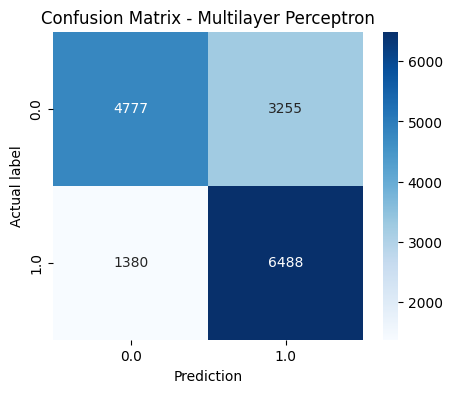

In [112]:
# Build and plot the confusion matrix for MLP.
sixthModel = "Multilayer Perceptron"

confMatrixMLP = predMLP.groupBy("label", "prediction").count()

plotMatConfusion(confMatrixMLP, sixthModel)

#### Confusion Matrix interpretation

- The confusion matrix shows that:

    - 4777 clients were correctly classified as non-subscribers (true negatives).
    - 6488 clients were correctly classified as subscribers (true positives).
    - 3255 clients were incorrectly classified as subscribers when they were not (false positives).
    - 1380 clients were incorrectly classified as non-subscribers when they actually subscribed (false negatives).

- This indicates that the model generates a large number of false positives. From a business perspective, this means that many clients who are not interested would still be targeted by the marketing campaign, potentially increasing unnecessary operational costs.

- Although the model correctly identifies many subscribers, the high number of incorrect positive predictions reduces its overall reliability compared to the other evaluated models.

##### - **ROC area for MLP.**

ROC-AUC: 0.7886124778339615


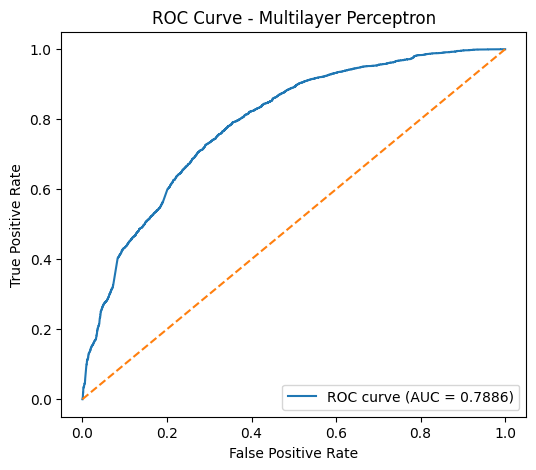

In [113]:
# Calculate and plot the ROC-AUC for the MLP model.
evaluaBinMLP = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")

aucMLP = evaluaBinMLP.evaluate(predMLP)

print("ROC-AUC:", aucMLP)

plotROC(predMLP, aucMLP, sixthModel)

#### ROC Curve interpretation

- The ROC AUC value of approximately 0.7886 indicates moderate discrimination capacity between the classes. The ROC curve remains above the diagonal reference line, meaning that the model still performs better than random classification, although its predictive capability is weaker than the previous models.

- An AUC below 0.80 suggests that the model has more difficulty separating subscribers from non-subscribers effectively.

##### Overfitting analysis

- No strong evidence of overfitting is observed. However, the lower performance metrics suggest that the model may not be capturing the data structure as effectively as the other classification techniques evaluated in this work.

### **29. Model comparison**


In [122]:
# Build a comparison table with the main model performance metrics.
# The new MLP model is included to compare its performance against the previous classifiers.

models = ['Logistic Regression', 'Decision Tree', 'Random Forest',
          'Gradient Boosted Tree', 'Support Vector Machine',
          'Multilayer Perceptron']

accuracy = [accuracyLR, accuracyDT, accuracyRF, accuracyGBT, accuracySVM, accuracyMLP]
precision = [precisionLR, precisionDT, precisionRF, precisionGBT, precisionSVM, precisionMLP]
recall = [recallLR, recallDT, recallRF, recallGBT, recallSVM, recallMLP]
f1 = [f1ScoreLR, f1ScoreDT, f1RF, f1GBT, f1SVM, f1MLP]
roc_auc = [rocLR, rocDT, aucRF, aucGBT, aucSVM, aucMLP]

tableModels = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1,
    'ROC-AUC': roc_auc
})

# Sort models from highest to lowest F1-score to identify the best overall performance.
tableModels = tableModels.sort_values(by='F1-score', ascending=False).reset_index(drop=True)

tableModels

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Gradient Boosted Tree,0.858050,0.859852,0.858050,0.857933,0.927876
1,Support Vector Machine,0.838050,0.838049,0.838050,0.838046,0.911429
2,Logistic Regression,0.835849,0.836047,0.835849,0.835797,0.911350
3,Random Forest,0.826730,0.830888,0.826730,0.826307,0.894182
4,Decision Tree,0.806289,0.806552,0.806289,0.806205,0.608187
5,Multilayer Perceptron,0.708491,0.721456,0.708491,0.704748,0.788612


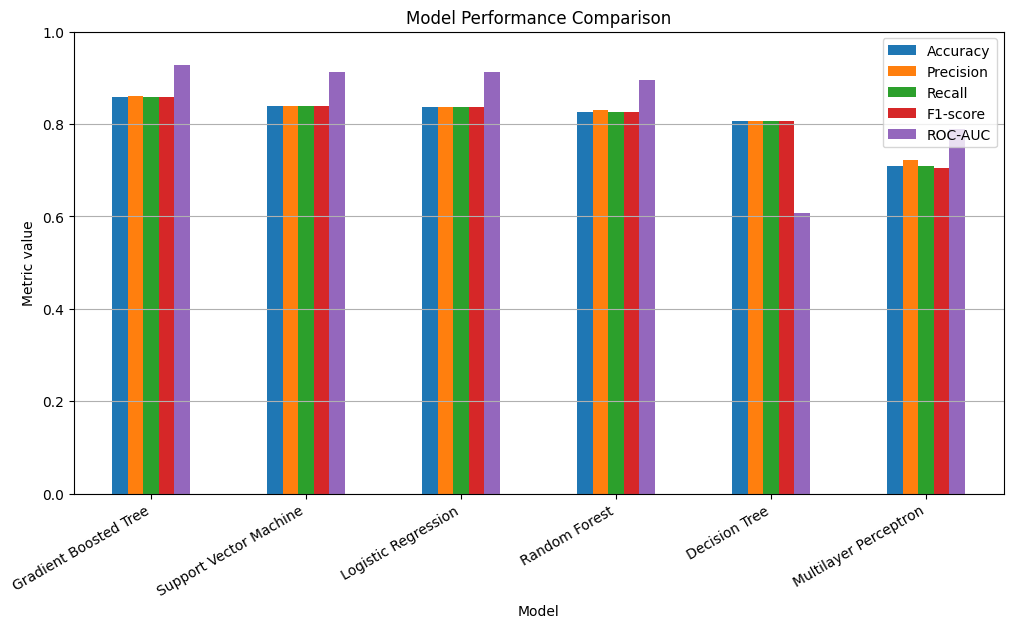

In [117]:
# Plot the model comparison table as grouped bars.
# This visualization compares the main evaluation metrics across all models, including MLP.
tableModels.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Metric value')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y')
plt.show()

### Model comparison analysis

- The comparison table includes the six evaluated models and allows the performance to be reviewed using accuracy, precision, recall, F1-score, and ROC-AUC.

- The table is sorted by F1-score because this metric summarizes the balance between precision and recall. This is useful in this case because both types of error are relevant for the campaign.

- The Gradient Boosted Tree model remains the main reference model because it obtained the best previous performance and also showed strong ROC-AUC behavior. The MLP model is added to verify whether a neural network can improve the results or whether the additional complexity is not necessary.

- From the grouped bar chart, it is possible to compare whether the new MLP model improves the previous models or if its metrics remain close to simpler techniques such as Logistic Regression or SVM.

- In general, the best model should not be selected only by accuracy. It is also important to consider false negatives, false positives, ROC-AUC, interpretability, and computational cost.

### **30. Additional value analysis: GBT feature importance**

This analysis helps identify which variables contributed the most to the GBT model.


In [119]:
# Extract feature importance from the trained GBT model.

importancesGBT = modelGBT.featureImportances.toArray()

featureImportanceGBT = pd.DataFrame({
    'Feature': featureNamesGBT,
    'Importance': importancesGBT
})

featureImportanceGBT = featureImportanceGBT.sort_values(
    by='Importance',
    ascending=False
).head(10)

featureImportanceGBT

,Feature,Importance
46,poutcome_oneHot_unknown,0.281694
47,poutcome_oneHot_failure,0.077510
38,month_oneHot_dec,0.058475
28,month_oneHot_jul,0.056722
25,default_oneHot_no,0.052431
49,poutcome_oneHot_other,0.048114
44,contact_oneHot_unknown,0.043842
33,month_oneHot_feb,0.039820
42,loan_oneHot_yes,0.035809
24,education_oneHot_unknown,0.027770


In [120]:
# Extract feature names from the metadata of the final features vector.

attrs = predGBT.schema["features"].metadata["ml_attr"]["attrs"]

featureNamesGBT = []

for attr_type in attrs:
    for attr in attrs[attr_type]:
        featureNamesGBT.append(attr["name"])

print("Feature names:", len(featureNamesGBT))
print("Importances:", len(importancesGBT))


Feature names: 50
Importances: 50


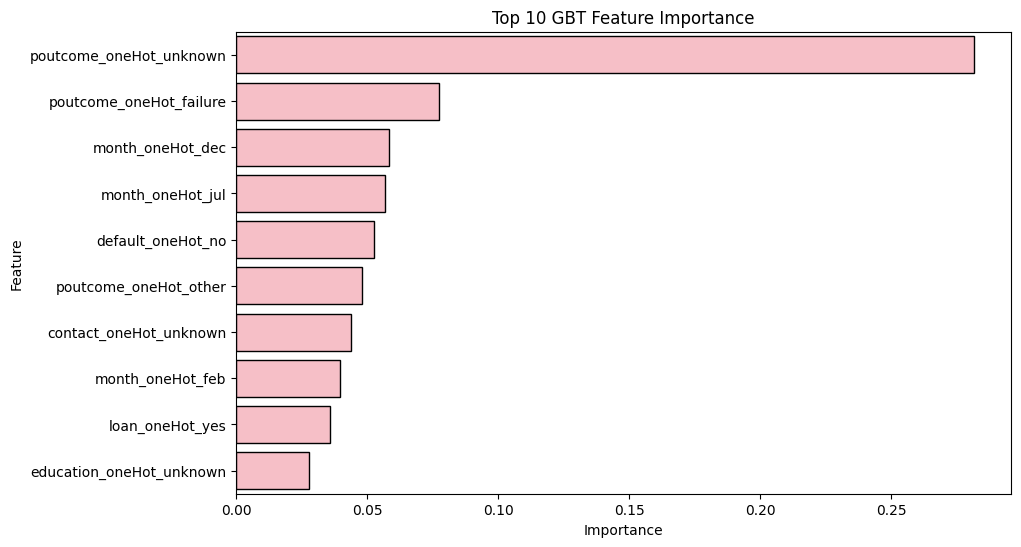

In [121]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=featureImportanceGBT,
    x='Importance',
    y='Feature',
    color='lightpink',
    edgecolor='black'
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 GBT Feature Importance')

plt.show()

### GBT Feature-importance analysis

- The analysis shows that the variables related to `poutcome` have the greatest contribution to the GBT model, especially `poutcome_oneHot_unknown`, which presents the highest importance value by a considerable margin.

- This suggests that information about the outcome of previous campaigns is highly relevant for predicting whether a client will subscribe to the term deposit.

- Additionally, some variables related to the contact month, such as `month_oneHot_dec`, `month_oneHot_jul`, and `month_oneHot_feb`, also appear among the most important predictors. This indicates that the period in which the campaign is performed may influence customer behavior and subscription probability.

- Variables associated with financial and customer conditions, such as `loan_oneHot_yes` and `default_oneHot_no`, also contribute to the model, although with lower importance values.

- The graph shows that the importance distribution is not uniform, since a few variables concentrate a large part of the predictive contribution while the remaining variables have much smaller effects.

- Overall, the analysis suggests that previous campaign outcomes and temporal variables are the strongest predictors within the GBT classification model.

Additionally, this feature importance analysis helps explain why GBT achieved the best overall performance, since the model was able to identify and prioritize the variables with the greatest predictive contribution.

### **31. Final conclusions** 

1. This work allowed a complete classification process to be developed using different machine learning techniques. Throughout the notebook, it was possible to understand how preprocessing, exploratory analysis, model construction, and evaluation are connected within a real predictive problem.

2. The exploratory analysis and data cleaning stage were especially important because they helped identify outliers, variable distributions, class imbalance, and relationships between predictors and the target variable. Additionally, the graphs and descriptive analysis made it easier to better understand the behavior of the dataset before training the models.

3. Different classification models were evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosted Tree, Support Vector Machine, and Multilayer Perceptron. Each model presented different strengths in terms of interpretability, predictive performance, and generalization capability. Ensemble methods such as Random Forest and GBT showed stronger predictive behavior compared to simpler models.

4. According to the evaluation metrics and ROC curves, the Gradient Boosted Tree model achieved the best overall performance, obtaining the highest accuracy, F1-score, and ROC-AUC values. The confusion matrices also showed that this model correctly classified a large number of subscribers while reducing false negatives, making it the strongest model for this classification problem.

### **32. Recommendations**

1. For this classification problem, the model with the best balance between F1-score, ROC-AUC, and business interpretation should be prioritized, not only the model with the highest accuracy.

2. False negatives should be monitored because they represent clients who actually subscribed but were not identified by the model. In a marketing campaign, this means losing potential customers.

3. The GBT model is recommended as the main candidate if it continues to show the best performance after including the new MLP model. However, Logistic Regression or SVM may be considered if a simpler and more interpretable model is required.

4. Future improvements may include hyperparameter tuning, cross-validation, and testing the models without variables that are only available after the customer interaction.

### **33. References**

- Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing*. Decision Support Systems, 62, 22–31.
- UCI Machine Learning Repository. *Bank Marketing Data Set*.
- Apache Spark Documentation. *MLlib: Classification and Regression*.
- Apache Spark Documentation. *Multilayer Perceptron Classifier*.
- scikit-learn Documentation. *ROC metrics and ROC curves*.

In [ ]:
# Stop the Spark session at the end of the notebook.
sparkCuellar.stop()
